In [1]:
import pandas as pd
import numpy as np
import os
import json
from scipy import constants
import matplotlib.pyplot as plt
import sympy
import random
from ase.io import read

/home/paolo/.conda/envs/pymc_env/lib/python3.12/site-packages/numpy/_core/getlimits.py:552: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


In [2]:
from sympy import symbols, simplify, sin, expand
import sympy as sp
import pymc as pm
import arviz as az

In [3]:
atoms_train = read("/home/paolo/Na_dataset/train_Na_new.xyz", index=":")
atoms_test = read("/home/paolo/Na_dataset/test_Na_new.xyz", index=":")

In [4]:
data_train = pd.concat(
    [pd.DataFrame([a.info for a in atoms_train]),
     pd.DataFrame({'cub_root_V': [a.get_volume()**(1/3) for a in atoms_train]})],
    axis=1
)
data_test = pd.concat(
    [pd.DataFrame([a.info for a in atoms_test]),
     pd.DataFrame({'cub_root_V': [a.get_volume()**(1/3) for a in atoms_test]})],
    axis=1
)

In [5]:
data_train

,Ea,B,N,O,F,Na,Al,Si,P,S,...,face-area-max,face-area-avg,face-area-min,face-area-count,pockets-per-ion,pockets-per-volume,paths-per-ion,paths-per-volume,poly_dist_avg_fixed,cub_root_V
0,0.365113,0.000000,0.0,0.631387,0.000000,0.127737,0.000000,0.000000,0.171533,0.000000,...,10.973040,2.521378,2.554994e-06,24.784055,5.371429,0.046887,45.342857,0.395793,0.385197,25.218719
1,0.425024,0.000000,0.0,0.467925,0.000000,0.184906,0.000000,0.000000,0.135849,0.000000,...,11.777366,2.837638,8.278834e-07,29.008265,1.173469,0.011507,5.484694,0.053782,0.375974,27.138803
2,0.274638,0.113043,0.0,0.000000,0.000000,0.208696,0.108696,0.000000,0.000000,0.304348,...,15.033404,3.383426,2.368494e-11,39.474009,2.583333,0.021100,14.566667,0.118978,0.080752,30.858072
3,0.324737,0.000000,0.0,0.000000,0.000000,0.101124,0.000000,0.243446,0.033708,0.621723,...,12.877547,3.444336,5.345359e-06,40.587672,8.425926,0.032273,51.564815,0.197504,0.116010,30.436900
4,0.345059,0.000000,0.0,0.407692,0.000000,0.219231,0.000000,0.000000,0.161538,0.000000,...,15.090982,3.165906,4.092372e-09,35.067899,2.105263,0.021466,13.359649,0.136222,0.363843,28.172671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1036,0.321759,0.000000,0.0,0.000000,0.000000,0.241935,0.000000,0.000000,0.161290,0.451613,...,12.864103,3.268545,4.741584e-07,37.803003,1.360784,0.012972,5.980392,0.057011,0.091131,29.906856
1037,0.389788,0.000000,0.0,0.380711,0.106599,0.335025,0.177665,0.000000,0.000000,0.000000,...,8.761876,1.934795,1.569696e-06,12.466122,0.335859,0.008334,2.255051,0.055958,0.317510,25.176614
1038,0.393305,0.250000,0.0,0.500000,0.000000,0.250000,0.000000,0.000000,0.000000,0.000000,...,8.829005,1.864119,7.645468e-07,13.897762,0.412000,0.008600,1.924000,0.040160,0.368284,22.879676
1039,0.335168,0.000000,0.0,0.417969,0.000000,0.187500,0.000000,0.000000,0.027344,0.000000,...,13.544451,2.987695,7.102955e-06,32.194261,3.026042,0.029022,16.453125,0.157799,0.301010,27.152839


In [6]:
def initialize_units(df_iniz, med_flag = False):
    df = (df_iniz - df_iniz.mean()) / df_iniz.std()
    kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
    return {
        "E" : np.array(df['Ea'], dtype = 'float'),
        "cub_root_V" : np.array(df['cub_root_V'], dtype = 'float'),
        
        # Density in g/cm^3
        "density": np.array(df['density'], dtype='float'),
        # Average Atomic Volume
        "AAV": np.array(df['AAV'], dtype='float'),
        # Volume per anion
        "VPA": np.array(df['VPA'], dtype='float'),
        # -Na-Na (are just the Na-Na distances)
        "Na-Na": np.array(df['Na-Na'], dtype='float'),
        "Na-Na-max": np.array(df['Na-Na-max'], dtype='float'),
        "Na-Na-avg": np.array(df['Na-Na-avg'], dtype='float'),
        # -bottleneck (free distance available for a Na⁺ ion to pass through the narrowest part of a diffusion pathway formed by surrounding framework atoms (typically O²⁻, S²⁻, or halides))
        "bottleneck_min": np.array(df['bottleneck_min'], dtype='float'),
        "bottleneck_avg": np.array(df['bottleneck_avg'], dtype='float'),
        # -face-area   (area of the shared face between two neighboring Voronoi polyhedra corresponding to adjacent Na sites it represents the cross-sectional area available for Na⁺ migration between those sites)
        "face-area-max": np.array(df['face-area-max'], dtype='float'),
        "face-area-avg": np.array(df['face-area-avg'], dtype='float'),
        "face-area-min": np.array(df['face-area-min'], dtype='float'),
        # -pockets  (free-volume region in the crystal structure where a Na⁺ ion can reside with relatively low energy, typically corresponding to a stable or metastable Na site)
        "pockets-per-volume": np.array(df['pockets-per-volume'], dtype='float'),
        # -paths  (connected sequence of pockets linked by Voronoi faces and constrained by bottlenecks, forming a continuous route that allows Na⁺ ions to move through the crystal lattice)
        "paths-per-volume": np.array(df['paths-per-volume'], dtype='float')
    }

In [7]:
kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
data = initialize_units(data_train)
T = 300
lnDvsE = pd.DataFrame({
    "sample_id": [f"s{j+1}" for j in range(len(data_train['Ea']))], 
    "E_T": data_train['Ea']/(kb*T),
    "rho": data['density'],
    "AAV": data['AAV'],
    "PF": data_train['PF'],
    "VPA": data['VPA'],
    "NBI": data_train['NBI'],
    "SBI": data_train['SBI'],
    "RBI": data_train['RBI'],
    "WE": data_train['weighted_electronegativity'],
    "B": data_train['B'],
    "N": data_train['N'],
    "S": data_train['S'],
    "O": data_train['O'],
    "F": data_train['F'],
    "Na": data_train['Na'],
    "Al": data_train['Al'],
    "Si": data_train['Si'],
    "P": data_train['P'],
    "Cl": data_train['Cl'],
    "Ge": data_train['Ge'],
    "Br": data_train['Br'],
    "I": data_train['I'],

    # Volume
    "cub_root_V" : data['cub_root_V'],
    
    # Na–Na distances
    "Na-Na": data['Na-Na'],
    "Na-Na-max": data['Na-Na-max'],
    "Na-Na-avg": data['Na-Na-avg'],

    # Bottleneck descriptors
    "bottleneck_min": data['bottleneck_min'],
    "bottleneck_avg": data['bottleneck_avg'],

    # Polyhedral distortion
    "poly_dist_max": data_train['poly_dist_max'],
    "poly_dist_std": data_train['poly_dist_std'],
    "poly_dist_avg": data_train['poly_dist_avg'],
    "poly_dist_avg_fixed": data_train['poly_dist_avg_fixed'],

    # Voronoi face areas
    "face-area-max": data['face-area-max'],
    "face-area-avg": data['face-area-avg'],
    "face-area-min": data['face-area-min'],
    "face-area-count": data_train['face-area-count'],

    # Pockets
    "pockets-per-ion": data_train['pockets-per-ion'],
    "pockets-per-volume": data['pockets-per-volume'],

    # Paths
    "paths-per-ion": data_train['paths-per-ion'],
    "paths-per-volume": data['paths-per-volume'],

    # Target
    "ln_D": data_train['logD']
})    

In [8]:
n_feat = 40
lnDvsE.to_csv(f"/home/paolo/Thesis/Na/data/desc_dim/Na_lndiff{n_feat}_temp300_unitless3.csv", index=False)
data_file = f"/home/paolo/Thesis/Na/data/desc_dim/Na_lndiff{n_feat}_temp300_unitless3.csv"
os.environ["SISSOPP_TUT_DAT_FILE"] = data_file

In [9]:
# Try the fit with the exact functional form
rung = 1
desc_dim = 3
Diff_json = {
    'data_file': data_file,
     'property_key': 'ln_D',
     'desc_dim': desc_dim,
     'n_sis_select': 10,
     'max_rung': rung,
     'calc_type': 'regression',
     'min_abs_feat_val': 1e-05,
     'max_abs_feat_val': 1e8,
     'n_residual': 10,
     'n_models_store': 10,
     'leave_out_frac': 0.0,
     'leave_out_inds': [],
     'opset': ['exp', 'add', 'sub', 'mult', 'div', 'sin', 'cos']
}
json.dump(Diff_json, open(f"/home/paolo/Thesis/Na/data/desc_dim/lndiff{n_feat}_{rung}_{desc_dim}_unitless3.json", "w"), indent=4)

In [ ]:
# Rung=1 desc_dim=3 Features=40 'E_T': E/(kb*T), 'rho': density, 'AAV': AAV, 'PF': PF, 'VPA': VPA, 'NBI': NBI, 'SBI': SBI,  'RBI': RBI, 'WE': WE, 
        # 'B': B, 'N': N, 'S': S, 'O': O, 'F': F, 'Na': Na, 'Al': Al, 'Si': Si, 'P': P, 'Cl': Cl, 'Ge': Ge, 'Br': Br, 'I': I, 'cub_root_V': V^(1/3),
        # "Na-Na": data['Na-Na'], "Na-Na-max": data['Na-Na-max'], "Na-Na-avg": data['Na-Na-avg'], "bottleneck_min": data['bottleneck_min'], "bottleneck_avg": data['bottleneck_avg'],
        # "poly_dist_max": data['poly_dist_max'], "poly_dist_std": data['poly_dist_std'], "poly_dist_avg": data['poly_dist_avg'], "poly_dist_avg_fixed": data['poly_dist_avg_fixed'],
        # "face-area-max": data['face-area-max'], "face-area-avg": data['face-area-avg'], "face-area-min": data['face-area-min'], "face-area-count": data['face-area-count'],
        # "pockets-per-ion": data['pockets-per-ion'], "pockets-per-volume": data['pockets-per-volume'],
        # "paths-per-ion": data['paths-per-ion'], "paths-per-volume": data['paths-per-volume'],
# time input_parsing: 0.0446208 s
# Time to generate feat space: 0.0218646 s
# Projection time: 0.0015374 s
# Time to get best features on rank : 8.34e-05 s
# |---Complete final combination/selection from all ranks: 0.0003655 s
# Time for SIS: 0.002564 s
# Time for l0-norm: 0.0040541 s
# Projection time: 0.0071285 s
# Time to get best features on rank : 7.72e-05 s
# |---Complete final combination/selection from all ranks: 0.0002958 s
# Time for SIS: 0.0091022 s
# Time for l0-norm: 0.0051416 s
# Projection time: 0.0052374 s
# Time to get best features on rank : 7.81e-05 s
# |---Complete final combination/selection from all ranks: 0.0002955 s
# Time for SIS: 0.0074887 s
# Time for l0-norm: 0.0234237 s
# Train RMSE: 0.504806 Unitless
# c0 + a0 * (AAV - E_T)

# Train RMSE: 0.352047 Unitless
# c0 + a0 * (Al + O) + a1 * (face-area-avg - E_T)

# Train RMSE: 0.292567 Unitless
# c0 + a0 * (P + B) + a1 * (O - NBI) + a2 * (face-area-avg - E_T)
# Coefficients
# Task   a0                      a1                      a2                      c0
# all ,  2.368735260553136e+00, -2.926724388797800e+00,  6.592022782480937e-01, -1.284806448469591e+01,  

In [7]:
def extract_dd3(ms = 10, rung=1, feat = 40):
    '''Extract the formulas and the values of the parameters from the SISSO output for desc_dim=3'''
    dd = 3
    formulas = []
    a0_list = []
    a1_list = []
    a2_list = []
    c0_list = []
    models_stored = ms
    for i in range(models_stored):
        filename = f'/home/paolo/Thesis/Na/data/desc_dim/models_lndiff{feat}_{rung}_{dd}_unitless/train_dim_{dd}_model_{i}.dat'
        with open(filename, 'r') as f:
            line1 = next(f)               # First line
            for _ in range(4): next(f)    # Skip lines 2 to 5
            line6 = next(f)               # Sixth line
            formula = line1.replace('#', '').strip()
            # Split line6 by spaces
            parts = line6.strip().split()
            a0_i = parts[3].rstrip(',')
            a1_i = parts[4].rstrip(',')
            a2_i = parts[5].rstrip(',')
            c0_i = parts[6].rstrip(',')
    
            formulas.append(formula)
            a0_list.append(a0_i)
            a1_list.append(a1_i)
            a2_list.append(a2_i)
            c0_list.append(c0_i)
            #print(formula, a0_i, a1_i, c0_i)
    return(formulas, a0_list, a1_list, a2_list, c0_list)

In [8]:
raw_formulas, a0_list, a1_list, a2_list, c0_list = extract_dd3()

In [9]:
raw_formulas

['c0 + a0 * (P + B) + a1 * (O - NBI) + a2 * (face-area-avg - E_T)',
 'c0 + a0 * (Al - B) + a1 * (O - NBI) + a2 * (face-area-avg - E_T)',
 'c0 + a0 * (poly_dist_std + B) + a1 * (O - NBI) + a2 * (face-area-avg - E_T)',
 'c0 + a0 * (P + B) + a1 * (Al + O) + a2 * (face-area-avg - E_T)',
 'c0 + a0 * (poly_dist_std + B) + a1 * (Al + O) + a2 * (face-area-avg - E_T)',
 'c0 + a0 * (B + WE) + a1 * (Al + O) + a2 * (AAV - E_T)',
 'c0 + a0 * (B + WE) + a1 * (Al + O) + a2 * (face-area-avg - E_T)',
 'c0 + a0 * (Na - B) + a1 * (O - NBI) + a2 * (face-area-avg - E_T)',
 'c0 + a0 * (Al + Na) + a1 * (O - NBI) + a2 * (face-area-avg - E_T)',
 'c0 + a0 * (P + B) + a1 * (O - NBI) + a2 * (AAV - E_T)']

In [10]:
def sanitize(expr):
    return (
        expr
        .replace('Na-Na-avg', 'Na_Na_avg')
        .replace('Na-Na-max', 'Na_Na_max')
        .replace('Na-Na', 'Na_Na')
        .replace('face-area-avg', 'face_area_avg')
        .replace('face-area-max', 'face_area_max')
        .replace('face-area-min', 'face_area_min')
        .replace('face-area-count', 'face_area_count')
        .replace('cub_root_V', 'cub_root_V')
        .replace('pockets-per-ion', 'pockets_per_ion')
        .replace('pockets-per-volume', 'pockets_per_volume')
        .replace('paths-per-ion', 'paths_per_ion')
        .replace('paths-per-volume', 'paths_per_volume')
    )

In [11]:
formulas = [sanitize(f) for f in raw_formulas]
formulas

['c0 + a0 * (P + B) + a1 * (O - NBI) + a2 * (face_area_avg - E_T)',
 'c0 + a0 * (Al - B) + a1 * (O - NBI) + a2 * (face_area_avg - E_T)',
 'c0 + a0 * (poly_dist_std + B) + a1 * (O - NBI) + a2 * (face_area_avg - E_T)',
 'c0 + a0 * (P + B) + a1 * (Al + O) + a2 * (face_area_avg - E_T)',
 'c0 + a0 * (poly_dist_std + B) + a1 * (Al + O) + a2 * (face_area_avg - E_T)',
 'c0 + a0 * (B + WE) + a1 * (Al + O) + a2 * (AAV - E_T)',
 'c0 + a0 * (B + WE) + a1 * (Al + O) + a2 * (face_area_avg - E_T)',
 'c0 + a0 * (Na - B) + a1 * (O - NBI) + a2 * (face_area_avg - E_T)',
 'c0 + a0 * (Al + Na) + a1 * (O - NBI) + a2 * (face_area_avg - E_T)',
 'c0 + a0 * (P + B) + a1 * (O - NBI) + a2 * (AAV - E_T)']

In [12]:
a0 = np.array(a0_list, dtype=float)
a1 = np.array(a1_list, dtype=float)
a2 = np.array(a2_list, dtype=float)
c0 = np.array(c0_list, dtype=float)

In [13]:
# define symbols
a0_sym, a1_sym, a2_sym, c0_sym = sp.symbols('a0 a1 a2 c0')
symbols = sp.symbols(
    '''
    E_T B N O F Na Al Si P S Cl Ge Br I
    density AAV PF SBI RBI VPA NBI WE cub_root_V
    bottleneck_min bottleneck_avg
    poly_dist_avg poly_dist_max poly_dist_std poly_dist_avg_fixed
    Na_Na Na_Na_max Na_Na_avg
    face_area_max face_area_avg face_area_min face_area_count
    pockets_per_ion pockets_per_volume
    paths_per_ion paths_per_volume
    '''
)

locals_dict = {s.name: s for s in symbols}
# convert strings to sympy expressions
sympy_exprs = [sp.sympify(f, locals=locals_dict) for f in formulas]

pruned = []
# Prunes the coefficients that will be added later as distributions
for f in sympy_exprs:
    row = [
        sp.simplify(f.coeff(a0_sym)),
        sp.simplify(f.coeff(a1_sym)),
        sp.simplify(f.coeff(a2_sym)),
    ]
    pruned.append(row)

pruned

[[B + P, -NBI + O, -E_T + face_area_avg],
 [Al - B, -NBI + O, -E_T + face_area_avg],
 [B + poly_dist_std, -NBI + O, -E_T + face_area_avg],
 [B + P, Al + O, -E_T + face_area_avg],
 [B + poly_dist_std, Al + O, -E_T + face_area_avg],
 [B + WE, Al + O, AAV - E_T],
 [B + WE, Al + O, -E_T + face_area_avg],
 [-B + Na, -NBI + O, -E_T + face_area_avg],
 [Al + Na, -NBI + O, -E_T + face_area_avg],
 [B + P, -NBI + O, AAV - E_T]]

In [14]:
vars_ = [
    locals_dict[k] for k in [
        "E_T", 'B', 'N', 'S', 'O', 'F', 'Na', 'Al', 'Si', 'P', 'Cl', 'Ge', 'Br', 'I', 'density', 'AAV', 'PF', 'NBI', 'SBI', 'RBI', 'VPA', 'WE', 'cub_root_V', 
        'Na_Na', 'Na_Na_max', 'Na_Na_avg', 'bottleneck_min', 'bottleneck_avg', 'poly_dist_max', 'poly_dist_std', 'poly_dist_avg', 'poly_dist_avg_fixed',
        'face_area_max', 'face_area_avg', 'face_area_min', 'face_area_count', 
        'pockets_per_ion', 'pockets_per_volume', 'paths_per_ion', 'paths_per_volume',
    ]
]
# Feature functions
Phi = [
    sp.lambdify(vars_, row, modules="numpy")
    for row in pruned
]

In [15]:
data = initialize_units(data_train)
kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
T = 300
X = np.array([
    phi(
        data_train['Ea']/(kb*T),
        data_train['B'],
        data_train['N'],
        data_train['S'],
        data_train['O'],
        data_train['F'],
        data_train['Na'],
        data_train['Al'],
        data_train['Si'],
        data_train['P'],
        data_train['Cl'],
        data_train['Ge'],
        data_train['Br'],
        data_train['I'],
        
        data['density'],
        data['AAV'],
        data_train['PF'],
        data_train['NBI'],
        data_train['SBI'],
        data_train['RBI'],
        data['VPA'],
        data_train['weighted_electronegativity'],
        
        
        # Volume
        data['cub_root_V'],
        
        # Na–Na distances
        data['Na-Na'],
        data['Na-Na-max'],
        data['Na-Na-avg'],
        
        # Bottleneck descriptors
        data['bottleneck_min'],
        data['bottleneck_avg'],
        
        # Polyhedral distortion
        data_train['poly_dist_max'],
        data_train['poly_dist_std'],
        data_train['poly_dist_avg'],
        data_train['poly_dist_avg_fixed'],
        
        # Voronoi face areas
        data['face-area-max'],
        data['face-area-avg'],
        data['face-area-min'],
        data_train['face-area-count'],
        
        # Pockets
        data_train['pockets-per-ion'],
        data['pockets-per-volume'],
        
        # Paths
        data_train['paths-per-ion'],
        data['paths-per-volume'],
    )
    for phi in Phi
])

In [16]:
data2 = initialize_units(data_test)
kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
T = 300
X_test = np.array([
    phi(
        data_test['Ea']/(kb*T),
        data_test['B'],
        data_test['N'],
        data_test['S'],
        data_test['O'],
        data_test['F'],
        data_test['Na'],
        data_test['Al'],
        data_test['Si'],
        data_test['P'],
        data_test['Cl'],
        data_test['Ge'],
        data_test['Br'],
        data_test['I'],
        
        data2['density'],
        data2['AAV'],
        data_test['PF'],
        data_test['NBI'],
        data_test['SBI'],
        data_test['RBI'],
        data2['VPA'],
        data_test['weighted_electronegativity'],
        
        
        # Volume
        data2['cub_root_V'],
        
        # Na–Na distances
        data2['Na-Na'],
        data2['Na-Na-max'],
        data2['Na-Na-avg'],
        
        # Bottleneck descriptors
        data2['bottleneck_min'],
        data2['bottleneck_avg'],
        
        # Polyhedral distortion
        data_test['poly_dist_max'],
        data_test['poly_dist_std'],
        data_test['poly_dist_avg'],
        data_test['poly_dist_avg_fixed'],
        
        # Voronoi face areas
        data2['face-area-max'],
        data2['face-area-avg'],
        data2['face-area-min'],
        data_test['face-area-count'],
        
        # Pockets
        data_test['pockets-per-ion'],
        data2['pockets-per-volume'],
        
        # Paths
        data_test['paths-per-ion'],
        data2['paths-per-volume'],
    )
    for phi in Phi
])

In [17]:
# 10 formulas with 3 subformulas each for each of the 1041 entries of the dataset
X.shape, X_test.shape

((10, 3, 1041), (10, 3, 261))

In [18]:
X

array([[[ 1.71532847e-01,  1.35849057e-01,  1.13043478e-01, ...,
          2.50000000e-01,  2.73437500e-02,  0.00000000e+00],
        [-2.71547730e-02, -1.81544258e-01, -4.81237695e-01, ...,
         -1.17032767e-01, -2.23337681e-01, -2.70581799e-01],
        [-1.47542159e+01, -1.65227001e+01, -9.75812089e+00, ...,
         -1.69856169e+01, -1.27864402e+01, -1.86348812e+01]],

       [[ 0.00000000e+00,  0.00000000e+00, -4.34782609e-03, ...,
         -2.50000000e-01,  0.00000000e+00,  0.00000000e+00],
        [-2.71547730e-02, -1.81544258e-01, -4.81237695e-01, ...,
         -1.17032767e-01, -2.23337681e-01, -2.70581799e-01],
        [-1.47542159e+01, -1.65227001e+01, -9.75812089e+00, ...,
         -1.69856169e+01, -1.27864402e+01, -1.86348812e+01]],

       [[ 7.50342944e-02,  1.27542739e-01,  1.94912787e-01, ...,
          3.35608080e-01,  1.84044368e-01,  1.40668355e-01],
        [-2.71547730e-02, -1.81544258e-01, -4.81237695e-01, ...,
         -1.17032767e-01, -2.23337681e-01, -2.705

In [20]:
np.max(c0), np.max(a0), np.max(a1), np.max(a2)

(np.float64(-11.46406049733664),
 np.float64(2.783983941822258),
 np.float64(-1.850484963149962),
 np.float64(0.6792588351395807))

In [18]:
traces1 = []
ppcs = []
models_stored = 10
for i in range(models_stored):
    with pm.Model() as model:
        # Select the i-th column
        f = X[i, :, :]
        f_test = X_test[i, :, :]

        # Priors weakly informative
        c0_coeff = pm.Normal("c0", mu=c0[i], sigma=5)
        a0_coeff = pm.Normal("a0", mu=a0[i], sigma=5)
        a1_coeff = pm.Normal("a1", mu=a1[i], sigma=5)
        a2_coeff = pm.Normal("a2", mu=a2[i], sigma=5)
        sigma = pm.HalfNormal("sigma", sigma=2)

        # Linear parametrization
        mu = c0_coeff + a0_coeff * f[0, :] + a1_coeff * f[1, :] + a2_coeff * f[2, :]

        # Likelihood
        y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=data_train['logD'])

        # Sample from posterior
        # Sequential montecarlo chiedi spiegazione
        trace = pm.smc.sample_smc(draws=4000, chains=4, threshold=0.5, random_seed = 123)

        # Posterior predictive for the TEST set:
        # Create a new RV for test predictions using the same parameters.
        mu_test = pm.Deterministic("mu_test", c0_coeff + a0_coeff * f_test[0, :] + a1_coeff * f_test[1, :] + a2_coeff * f_test[2, :])
        y_test_rv = pm.Normal("y_test", mu=mu_test, sigma=sigma)
        
        ppc = pm.sample_posterior_predictive(
        trace,
        var_names=["y_test"],
        random_seed=123
    )
        traces1.append(trace)
        ppcs.append(ppc)

        idata = trace.posterior
        az.to_netcdf(idata, f"trace_model_{i}.nc")
        az.to_netcdf(ppc, f"pp_model_{i}.nc")

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

Sampling: [y_test]


Output()

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


...

Output()

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

Sampling: [y_test]


Output()

In [19]:
c0[0], a0[0], a1[0], a2[0]

(np.float64(-12.84806448469591),
 np.float64(2.368735260553136),
 np.float64(-2.9267243887978),
 np.float64(0.6592022782480937))

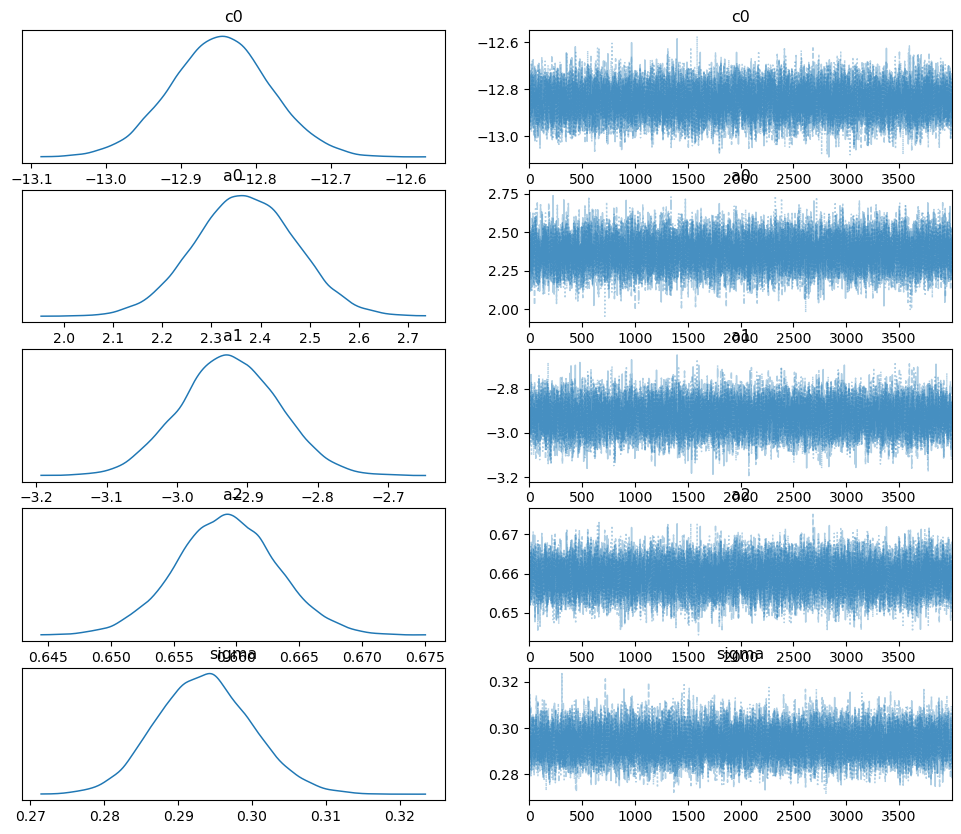

In [20]:
az.plot_trace(traces1[0], combined=True);

In [23]:
# log marginal likelihood for model 0: 6 chains and 11 draws per chain
traces1[1].sample_stats["log_marginal_likelihood"].values 

array([[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, np.float64(-236.84735187586816)],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, np.float64(-237.7502391661318)],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, np.float64(-236.6877563711378)],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, np.float64(-237.40454107829066)]], dtype=object)

In [24]:
marginal_likelihoods = []
log_marginal_likelihoods = []
for i in range(models_stored):
    log_ml_raw = traces1[i].sample_stats["log_marginal_likelihood"].values
    # Flatten possible nested lists and cast to floats
    flattened = []
    for row in log_ml_raw.ravel():
        # If it’s a list, tuple, or NumPy array then flattened.extend(row) appends all items inside it (not the list itself).
        if isinstance(row, (list, tuple, np.ndarray)):
            flattened.extend(row)
        # Otherwise (a plain number or NaN) then flattened.append(row) just adds the single value.
        else:
            flattened.append(row)
    #print(flattened)
    # This ensures that everything inside flattened is a single scalar number, not a list or array.
    log_ml = np.array(flattened, dtype=float)
    # Checks that the entry is effectively a number
    log_ml = log_ml[~np.isnan(log_ml)]
    print(log_ml)
    # Computes the mean
    mean_log_ml = np.mean(log_ml)
    log_marginal_likelihoods.append(mean_log_ml)

[-225.33534071 -225.43328443 -226.08691952 -225.33328291]
[-236.84735188 -237.75023917 -236.68775637 -237.40454108]
[-262.55615556 -261.7127292  -261.99063451 -262.98091322]
[-269.75984188 -270.18833376 -269.11993105 -270.44329876]
[-293.81352097 -293.32341545 -293.16603464 -293.19833477]
[-317.40074987 -315.31799362 -316.40945841 -315.88325139]
[-317.16975075 -316.95926149 -315.00020286 -316.81630912]
[-318.31149174 -319.28997307 -319.11550889 -318.54237282]
[-325.9949122  -326.57350735 -325.88761155 -325.79247617]
[-332.11112385 -332.90562622 -331.91947382 -331.57825663]


In [25]:
log_marginal_likelihoods

[np.float64(-225.54720689268595),
 np.float64(-237.1724721228571),
 np.float64(-262.31010812537556),
 np.float64(-269.87785136158396),
 np.float64(-293.3753264567378),
 np.float64(-316.25286332529515),
 np.float64(-316.4863810527901),
 np.float64(-318.8148366289908),
 np.float64(-326.0621268186097),
 np.float64(-332.12862013017934)]

In [26]:
# Recovers the highest ml value and its related index, i.e. model
max_ml = np.max(log_marginal_likelihoods)
argmax_ml = np.argmax(log_marginal_likelihoods)
max_ml, argmax_ml 

(np.float64(-225.54720689268595), np.int64(0))

In [27]:
# Computes the marginal likelihood ratios between the given model and the benchmark
ml_diff = []
for i in range(models_stored):
    ml_diff.append(np.exp(-(log_marginal_likelihoods[argmax_ml] - log_marginal_likelihoods[i])))
ml_diff

[np.float64(1.0),
 np.float64(8.937405439721387e-06),
 np.float64(1.0816203655392217e-16),
 np.float64(5.59043661738135e-20),
 np.float64(3.488365281518802e-30),
 np.float64(4.046075047551012e-40),
 np.float64(3.2034538621181375e-40),
 np.float64(3.1216417846572007e-41),
 np.float64(2.2229255992849926e-44),
 np.float64(5.15561356274271e-47)]

In [28]:
np.argsort(ml_diff)

array([9, 8, 7, 6, 5, 4, 3, 2, 1, 0])

## Tempering

In [56]:
beta = np.array([1/64, 1/32, 1/16])
beta

array([0.015625, 0.03125 , 0.0625  ])

In [61]:
traces_temp = []
models_stored = 10
for i in range(models_stored):
    traces_i = []
    for j in beta:
        with pm.Model() as model:
            # Select the i-th column
            f = X[i, :, :]
            f_test = X_test[i, :, :]
    
            # Priors weakly informative
            c0_coeff = pm.Normal("c0", mu=c0[i], sigma=5)
            a0_coeff = pm.Normal("a0", mu=a0[i], sigma=5)
            a1_coeff = pm.Normal("a1", mu=a1[i], sigma=5)
            a2_coeff = pm.Normal("a2", mu=a2[i], sigma=5)
            sigma = pm.HalfNormal("sigma", sigma=2)
    
            # Linear parametrization
            mu = c0_coeff + a0_coeff * f[0, :] + a1_coeff * f[1, :] + a2_coeff * f[2, :]
    
    
            # Standard log-likelihood
            dist = pm.Normal.dist(mu=mu, sigma=sigma)
            logp = pm.logp(dist, data_train['logD'])

            # Tempered likelihood --> log (y| theta) = sum_n log(y_n|theta)
            pm.Potential("tempered_likelihood", j * logp.sum())
    
            # Sample from posterior
            # Sequential montecarlo
            trace = pm.smc.sample_smc(draws=4000, chains=4, threshold=0.5, random_seed = 123)
            #trace = pm.sample()
            traces_i.append(trace)
    traces_temp.append(traces_i)

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


...

Output()

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

In [62]:
traces_temp[0][0].sample_stats["log_marginal_likelihood"].values

array([[list([nan, nan, nan, nan, nan, nan, nan, nan, np.float64(-19.591638708885615)]),
        list([nan, nan, nan, nan, nan, nan, nan, nan, np.float64(-20.225226908068517)]),
        list([nan, nan, nan, nan, nan, nan, nan, nan, np.float64(-19.57904995596305)]),
        list([nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float64(-18.175093684416034)])]],
      dtype=object)

In [63]:
marginal_likelihoods_temp = []
log_marginal_likelihoods_temp = []
for i in range(models_stored):
    for j in range(len(beta)):
        log_ml_raw = traces_temp[i][j].sample_stats["log_marginal_likelihood"].values
    
        # Flatten possible nested lists and cast to floats
        flattened = []
        for row in log_ml_raw.ravel():
            # If it’s a list, tuple, or NumPy array then flattened.extend(row) appends all items inside it (not the list itself).
            if isinstance(row, (list, tuple, np.ndarray)):
                flattened.extend(row)
            # Otherwise (a plain number or NaN) then flattened.append(row) just adds the single value.
            else:
                flattened.append(row)
        # This ensures that everything inside flattened is a single scalar number, not a list or array.
        log_ml_temp = np.array(flattened, dtype=float)
        # Checks that the entry is effectively a number
        log_ml_temp = log_ml_temp[~np.isnan(log_ml_temp)]
        print(log_ml_temp)
        # Computes the mean
        mean_log_ml_temp = np.mean(log_ml_temp)
        log_marginal_likelihoods_temp.append(mean_log_ml_temp)

[-19.59163871 -20.22522691 -19.57904996 -18.17509368]
[-25.06900273 -24.55309042 -25.06982339 -25.25286498]
[-32.55234404 -33.67787763 -32.34426162 -32.79957043]
[-20.53316919 -19.90772839 -20.53495064 -20.2458151 ]
[-25.69372702 -26.15071549 -24.65638819 -25.28223792]
[-34.95274701 -33.99930131 -33.90899914 -34.12424406]
[-19.59989617 -20.08361742 -19.60146051 -19.95909084]
[-26.27721727 -25.58789681 -26.04735392 -25.04113717]
[-35.22751887 -35.63966927 -34.61046322 -34.46520907]
[-21.16043988 -20.40676943 -21.04388089 -20.06645926]
[-26.63163986 -27.66427161 -26.65276242 -26.842744  ]
[-36.5658575  -36.60424573 -34.72782559 -35.79777891]
[-21.0387173  -21.39020421 -21.16768381 -19.68066735]
[-27.39685869 -26.99456474 -27.6459058  -26.29062819]
[-36.8802434  -37.38159064 -36.93548348 -37.47408312]
[-22.66311939 -22.07891916 -22.90983646 -21.83985387]
[-27.9819193  -29.95734798 -29.81121847 -29.29192028]
[-40.30306659 -41.96571642 -38.81071533 -40.81580016]
[-23.17474768 -22.55640958 -

In [64]:
log_marginal_likelihoods_temp = np.array(log_marginal_likelihoods_temp).reshape(models_stored, len(beta))

In [65]:
log_marginal_likelihoods_temp # dim = (models_select=10, len(beta) = 4)

array([[-19.39275231, -24.98619538, -32.84351343],
       [-20.30541583, -25.44576715, -34.24632288],
       [-19.81101624, -25.73840129, -34.98571511],
       [-20.66938736, -26.94785447, -35.92392693],
       [-20.81931817, -27.08198936, -37.16785016],
       [-22.37293222, -29.26060151, -40.47382463],
       [-22.53133806, -28.66147759, -40.25806988],
       [-20.77960946, -27.81983466, -38.59245318],
       [-20.67825338, -27.9488757 , -38.93423233],
       [-20.44017105, -27.51782444, -38.97867634]])

In [66]:
# For each value of beta (comlumn) finds the representative with the highest marginal likelihood
for j in range(len(beta)):
    print(np.argmax(log_marginal_likelihoods_temp[:,j]))

0
0
0


In [67]:
ml_diff_temp = []
for i in range(models_stored):
    for j in range(len(beta)):
        # log_marginal_likelihoods_temp[np.argmax(marginal_likelihoods_temp[:,j]), j] --> log_marg_likelihood of the benchmark for that value of beta
        # e.g. if j=1 --> np.argmax(marginal_likelihoods_temp[:,j]) = (1,1) --> log_marginal_likelihoods_temp[1, 1]
        ml_diff_temp.append(np.exp(-(log_marginal_likelihoods_temp[np.argmax(log_marginal_likelihoods_temp[:,j]), j] - log_marginal_likelihoods_temp[i,j])))

In [68]:
ml_diff_temp = np.array(ml_diff_temp).reshape(models_stored, len(beta))
ml_diff_temp.T # Each row corresponds to the ml difference computed with the same value of beta for the different models

array([[1.00000000e+00, 4.01453521e-01, 6.58188496e-01, 2.78974458e-01,
        2.40132157e-01, 5.07836969e-02, 4.33440543e-02, 2.49859344e-01,
        2.76511998e-01, 3.50842198e-01],
       [1.00000000e+00, 6.31554036e-01, 4.71325702e-01, 1.40624918e-01,
        1.22972568e-01, 1.39203132e-02, 2.53422528e-02, 5.87984797e-02,
        5.16802119e-02, 7.95293565e-02],
       [1.00000000e+00, 2.45905135e-01, 1.17396090e-01, 4.59402564e-02,
        1.32423305e-02, 4.85509746e-04, 6.02419536e-04, 3.18615712e-03,
        2.26378091e-03, 2.16537244e-03]])

In [69]:
# Indices corresponding to the entries sorted in ascending order for beta = 1/8, 1/4, 1/2
np.argsort(ml_diff_temp.T)

array([[6, 5, 4, 7, 8, 3, 9, 1, 2, 0],
       [5, 6, 8, 7, 9, 4, 3, 2, 1, 0],
       [5, 6, 9, 8, 7, 4, 3, 2, 1, 0]])

In [38]:
ml_diff_hc = np.array([np.float64(1.0),
 np.float64(8.937405439721387e-06),
 np.float64(1.0816203655392217e-16),
 np.float64(5.59043661738135e-20),
 np.float64(3.488365281518802e-30),
 np.float64(4.046075047551012e-40),
 np.float64(3.2034538621181375e-40),
 np.float64(3.1216417846572007e-41),
 np.float64(2.2229255992849926e-44),
 np.float64(5.15561356274271e-47)])

In [39]:
# Indices corresponding to the entries sorted in ascending order for beta = 1
np.argsort(ml_diff_hc)

array([9, 8, 7, 6, 5, 4, 3, 2, 1, 0])

In [125]:
a = np.array([9, 8, 7, 6, 5, 4, 3, 2, 1, 0])
a[-1::-1]

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [134]:
ordering = np.vstack([
       [6, 5, 4, 7, 8, 3, 9, 1, 2, 0],
       [5, 6, 8, 7, 9, 4, 3, 2, 1, 0],
       [5, 6, 9, 8, 7, 4, 3, 2, 1, 0],
       [9, 8, 5, 6, 7, 4, 3, 2, 1, 0],
       [9, 8, 5, 7, 6, 4, 3, 2, 1, 0],
       [9, 8, 7, 6, 5, 4, 3, 2, 1, 0],
       [9, 8, 7, 6, 5, 4, 3, 2, 1, 0]])[:, ::-1]
ordering

array([[0, 2, 1, 9, 3, 8, 7, 4, 5, 6],
       [0, 1, 2, 3, 4, 9, 7, 8, 6, 5],
       [0, 1, 2, 3, 4, 7, 8, 9, 6, 5],
       [0, 1, 2, 3, 4, 7, 6, 5, 8, 9],
       [0, 1, 2, 3, 4, 6, 7, 5, 8, 9],
       [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
       [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]])

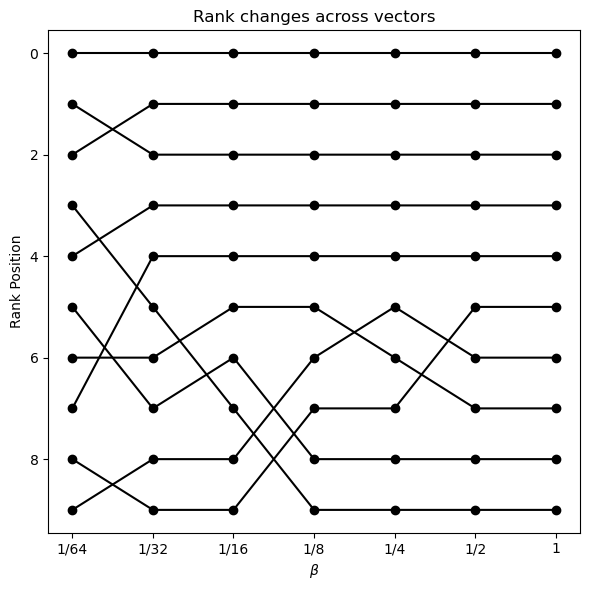

In [137]:
steps = range(ordering.shape[0])
values = range(10)

plt.figure(figsize=(6,6))

for v in values:
    positions = [np.where(ordering[i] == v)[0][0] for i in steps]
    plt.plot(steps, positions, marker='o', label=str(v), color = 'black')

plt.gca().invert_yaxis()
plt.xticks(steps, [r'1/64', r'1/32', r'1/16', r'1/8', r'1/4', r'1/2', r'1'])
plt.ylabel("Rank Position")
plt.xlabel(r"$\beta$")
plt.title("Rank changes across vectors")

#plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

## Best Model

In [61]:
c0_post = []
a0_post = []
a1_post = []
a2_post = []
for m in range(models_stored):
    c0_post.append(np.mean(traces1[m].posterior['c0'].values.flatten()))
    a0_post.append(np.mean(traces1[m].posterior['a0'].values.flatten()))
    a1_post.append(np.mean(traces1[m].posterior['a1'].values.flatten()))
    a2_post.append(np.mean(traces1[m].posterior['a2'].values.flatten()))
c0_post, a0_post

([np.float64(-12.848019506857435),
  np.float64(-12.430974590063993),
  np.float64(-13.008075342387864),
  np.float64(-11.464198785388794),
  np.float64(-11.505138782884117),
  np.float64(-13.74820924751658),
  np.float64(-12.949495493526923),
  np.float64(-13.011364660762771),
  np.float64(-12.725295122443892),
  np.float64(-12.439712147745421)],
 [np.float64(2.3696090604549696),
  np.float64(-1.6659505295367554),
  np.float64(2.2843564467512083),
  np.float64(2.00202757745012),
  np.float64(1.9125854040843864),
  np.float64(1.0993698343431815),
  np.float64(0.6636642959938969),
  np.float64(-1.3471645230984735),
  np.float64(-1.370481108086877),
  np.float64(2.7843698823909415)])

In [63]:
c0_post_std = []
a0_post_std = []
a1_post_std = []
a2_post_std = []
for m in range(models_stored):
    c0_post_std.append(np.std(traces1[m].posterior['c0'].values.flatten()))
    a0_post_std.append(np.std(traces1[m].posterior['a0'].values.flatten()))
    a1_post_std.append(np.std(traces1[m].posterior['a1'].values.flatten()))
    a2_post_std.append(np.std(traces1[m].posterior['a2'].values.flatten()))
c0_post_std, a0_post_std

([np.float64(0.06626310143326113),
  np.float64(0.06821548269129143),
  np.float64(0.07005042101249559),
  np.float64(0.051722786057374126),
  np.float64(0.05302141679329157),
  np.float64(0.11414567866857414),
  np.float64(0.11735938715840454),
  np.float64(0.07542728999225352),
  np.float64(0.07359627163142783),
  np.float64(0.07741263608806842)],
 [np.float64(0.10399666418208557),
  np.float64(0.07548630387665807),
  np.float64(0.1129456691853306),
  np.float64(0.10788553731337971),
  np.float64(0.1141233894445189),
  np.float64(0.04392339568432417),
  np.float64(0.04403275603387149),
  np.float64(0.08195012969619592),
  np.float64(0.08701504869865385),
  np.float64(0.11453050423821684)])

In [71]:
y_post = []
y_post_test = []
for m in range(models_stored):
    y_post.append(np.array(c0_post[m]) + X[m, 0, :] * np.array(a0_post[m]) + X[m, 1, :] * np.array(a1_post[m]) + X[m, 2, :] * np.array(a2_post[m]))
    y_post_test.append(np.array(c0_post[m]) + X_test[m, 0, :] * np.array(a0_post[m]) + X_test[m, 1, :] * np.array(a1_post[m]) + X_test[m, 2, :] * np.array(a2_post[m]))

In [74]:
y_post = np.array(y_post).T
y_post_test = np.array(y_post_test).T
y_post.shape

(1041, 10)

In [75]:
y_obs = np.tile(data_train['logD'], (10,1)).T
y_obs

array([[-22.44947812, -22.44947812, -22.44947812, ..., -22.44947812,
        -22.44947812, -22.44947812],
       [-22.98888401, -22.98888401, -22.98888401, ..., -22.98888401,
        -22.98888401, -22.98888401],
       [-17.55271247, -17.55271247, -17.55271247, ..., -17.55271247,
        -17.55271247, -17.55271247],
       ...,
       [-22.68866241, -22.68866241, -22.68866241, ..., -22.68866241,
        -22.68866241, -22.68866241],
       [-20.02651   , -20.02651   , -20.02651   , ..., -20.02651   ,
        -20.02651   , -20.02651   ],
       [-24.39240447, -24.39240447, -24.39240447, ..., -24.39240447,
        -24.39240447, -24.39240447]], shape=(1041, 10))

In [76]:
np.mean((y_obs - y_post)**2, axis = 0)

array([0.08559539, 0.08750929, 0.09202596, 0.0932136 , 0.0975398 ,
       0.10160064, 0.10170783, 0.10254651, 0.10390396, 0.10524059])

In [78]:
y_obs_test = np.tile(data_test['logD'], (10,1)).T

In [80]:
np.mean((y_obs_test - y_post_test)**2, axis = 0)

array([0.09671596, 0.08489997, 0.10113104, 0.10392379, 0.10348574,
       0.10165754, 0.10582795, 0.10717891, 0.10794813, 0.11081479])

## Calibration

In [19]:
files = [f"/home/paolo/Thesis/Na/mc_desc_dim_norm_lnD/trace_model_{i}.nc" for i in range(10)]
traces_list = [az.from_netcdf(f) for f in files]
traces1 = traces_list

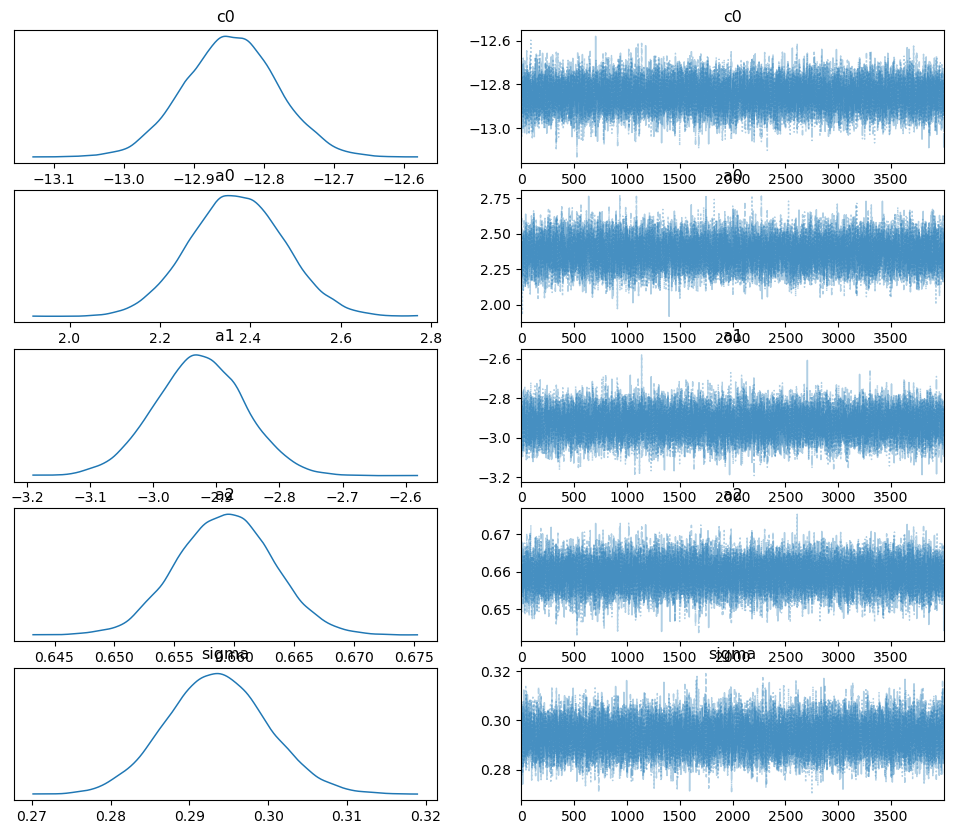

In [45]:
az.plot_trace(traces1[0], combined=True);

In [46]:
traces1[0].posterior['c0'].values.flatten()

array([-12.83715252, -12.81426106, -12.70208578, ..., -12.77954627,
       -13.09071031, -12.82789068], shape=(16000,))

In [20]:
# files = [f"/home/paolo/Thesis/Na/mc_desc_dim_norm2_lnD/trace_model_{i}.nc" for i in range(10)]
# traces_list = [az.from_netcdf(f) for f in files]
# traces1 = traces_list

In [20]:
np.random.seed(10)
c0_samples_list = []
a0_samples_list = []
a1_samples_list = []
a2_samples_list = []
sigma_samples_list = []
models_stored = 10
for m in range(models_stored):
# Draws 50 samples of the parameters from the posterior distribution
    c0_samples_list.append(np.random.choice(traces1[m].posterior['c0'].values.flatten(), size=200, replace=True))
    a0_samples_list.append(np.random.choice(traces1[m].posterior['a0'].values.flatten(), size=200, replace=True))
    a1_samples_list.append(np.random.choice(traces1[m].posterior['a1'].values.flatten(), size=200, replace=True))
    a2_samples_list.append(np.random.choice(traces1[m].posterior['a2'].values.flatten(), size=200, replace=True))
    sigma_samples_list.append(np.random.choice(traces1[m].posterior['sigma'].values.flatten(), size=200, replace=True))
c0_samples = np.array(c0_samples_list).T
a0_samples = np.array(a0_samples_list).T
a1_samples = np.array(a1_samples_list).T
a2_samples = np.array(a2_samples_list).T
sigma_samples = np.array(sigma_samples_list).T

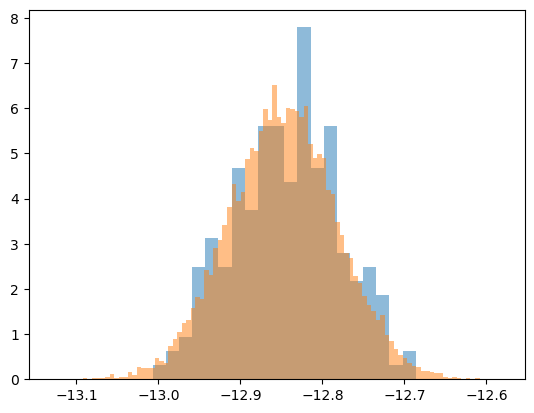

In [21]:
plt.hist(np.array(c0_samples.T[0]), alpha = 0.5, bins = 20, density = True)
plt.hist(traces1[0].posterior['c0'].values.flatten(), bins = 100, alpha = 0.5, density = True)
plt.show()

In [22]:
inputs = 1041
y_emp = np.zeros((inputs, models_stored))
for i in range(inputs):
    for m in range(models_stored):
        # Computes the mean over the ensemble for each of the 1041 points for each of the 10 formulas
        y_emp[i, m] = np.mean(c0_samples[:,m] + X[m, 0, i] * a0_samples[:,m] + X[m, 1, i] * a1_samples[:,m] + X[m, 2, i] * a2_samples[:,m])
# Empirical mean over the models
y_emp

array([[-22.08360155, -22.24830743, -22.56077115, ..., -22.27601111,
        -22.10672104, -22.28962337],
       [-22.88282915, -23.01890469, -23.12573431, ..., -22.940784  ,
        -22.81762494, -23.08099617],
       [-17.60013608, -17.66993733, -17.51876256, ..., -17.61616422,
        -17.80830089, -17.6690422 ],
       ...,
       [-23.10513533, -23.08747709, -23.16252665, ..., -23.19399165,
        -23.3988774 , -22.91919206],
       [-20.55532952, -20.40127921, -20.37829656, ..., -20.48062189,
        -20.33933589, -20.84109731],
       [-24.33825176, -24.19570933, -24.21735179, ..., -24.23109369,
        -24.14606919, -24.33277577]], shape=(1041, 10))

In [23]:
inputs = 1041
var_emp = np.zeros((inputs, models_stored))
for i in range(inputs):
    for m in range(models_stored):
        # Computes the variance over the ensemble for each of the 1041 points for each of the 10 formulas
        #var_emp[i, m] = np.var((c0_samples + Phi[i, m] * a0_samples + sigma_samples - y_emp[i,m])**2), ddof = 1)
        # Assuming decorrelation between noise and parameters
        var_emp[i, m] = 1/(200-1) * np.sum((c0_samples[:,m] + X[m, 0, i] * a0_samples[:,m] + X[m, 1, i] * a1_samples[:,m] + X[m, 2, i] * a2_samples[:,m] - y_emp[i,m])**2 
                                           + sigma_samples[:,m]**2)
# Empirical variance over the models
var_emp

array([[0.09546385, 0.09710452, 0.10067783, ..., 0.11499382, 0.11498462,
        0.11698389],
       [0.09638341, 0.09815136, 0.10201957, ..., 0.11670532, 0.11680696,
        0.11861119],
       [0.09396964, 0.09649229, 0.10059474, ..., 0.11254066, 0.11493234,
        0.11616609],
       ...,
       [0.09739165, 0.0985456 , 0.10295014, ..., 0.11678487, 0.11721874,
        0.11894812],
       [0.09400795, 0.09658108, 0.10042529, ..., 0.11378976, 0.11458233,
        0.11607028],
       [0.09725027, 0.09951245, 0.10364315, ..., 0.11971577, 0.11991506,
        0.12007948]], shape=(1041, 10))

In [24]:
y_obs = np.tile(data_train['logD'], (10,1)).T
y_obs

array([[-22.44947812, -22.44947812, -22.44947812, ..., -22.44947812,
        -22.44947812, -22.44947812],
       [-22.98888401, -22.98888401, -22.98888401, ..., -22.98888401,
        -22.98888401, -22.98888401],
       [-17.55271247, -17.55271247, -17.55271247, ..., -17.55271247,
        -17.55271247, -17.55271247],
       ...,
       [-22.68866241, -22.68866241, -22.68866241, ..., -22.68866241,
        -22.68866241, -22.68866241],
       [-20.02651   , -20.02651   , -20.02651   , ..., -20.02651   ,
        -20.02651   , -20.02651   ],
       [-24.39240447, -24.39240447, -24.39240447, ..., -24.39240447,
        -24.39240447, -24.39240447]], shape=(1041, 10))

In [25]:
# Columnwise mean of the given vector, i.e. mean over the features
R = np.mean((y_obs - y_emp)**2/var_emp, axis = 0)
R

array([0.90401805, 0.90192106, 0.91240489, 0.92836647, 0.93523764,
       0.79020651, 0.79128952, 0.89819785, 0.89897677, 0.90397873])

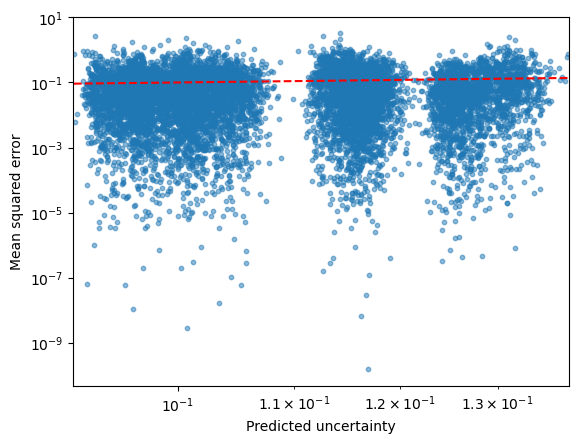

In [26]:
mse = np.abs(y_emp - y_obs)**2
plt.scatter(var_emp, mse, s=10, alpha=0.5)

# x limits based on data
xmin = var_emp[var_emp > 0].min()
xmax = var_emp.max()
plt.xlim(xmin*0.999, xmax*1.001)

# bisecting line y = x over the same range
xline = np.logspace(np.log10(xmin), np.log10(xmax), 200)
plt.plot(xline, xline, 'r--')

plt.loglog()
plt.xlabel("Predicted uncertainty")
plt.ylabel("Mean squared error")
plt.show()

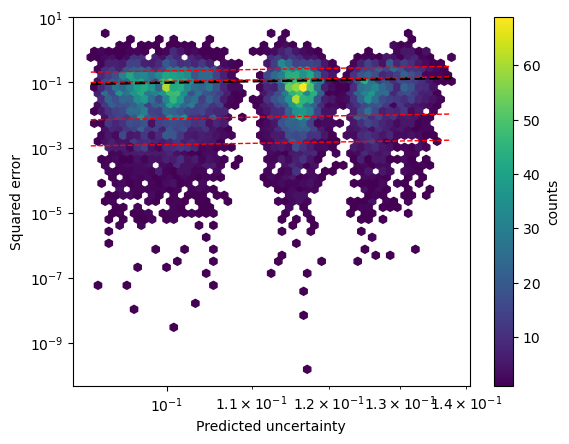

In [27]:
x = var_emp
y = (y_obs - y_emp)**2
# reference line
xmin, xmax = x.min(), x.max()
xline = np.logspace(np.log10(xmin), np.log10(xmax), 300)
plt.plot(xline, xline, 'k--', lw=2, label='y = x')

# quantiles in log space
log_ratios = np.log10(y / x)
quantiles = [0.1, 0.25, 0.75, 0.9]

for q in quantiles:
    q_val = 10 ** np.quantile(log_ratios, q)
    plt.plot(xline, q_val * xline,
             linestyle='--',
             color='red',
             lw=1)

# hexbin
plt.hexbin(x, y, gridsize=50, xscale='log', yscale='log',
           mincnt=1, cmap='viridis')

plt.colorbar(label='counts')
plt.xlabel("Predicted uncertainty")
plt.ylabel("Squared error")
plt.xscale('log')
plt.yscale('log')
#plt.ylim(xmin,xmax)
#plt.savefig('quant.png')
plt.show()

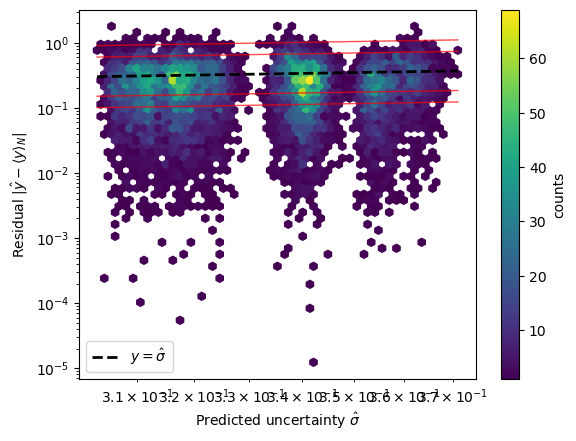

In [104]:
x = np.sqrt(var_emp)  # predicted uncertainty σ̂
y = np.abs(y_obs - y_emp)  # empirical error (not squared)

# reference line y = x  (error = σ)
xmin, xmax = x.min(), x.max()
xline = np.logspace(np.log10(xmin), np.log10(xmax), 300)
plt.plot(xline, xline, 'k--', lw=2, label=r'$y = \hat{\sigma}$')

# sigma lines: y = n·σ
sigma_multipliers = [1/3, 1/2, 2, 3]
for n in sigma_multipliers:
    plt.plot(xline, n * xline,
             linestyle='-',
             color='red',
             lw=1,
             alpha=0.7)

# hexbin
plt.hexbin(x, y, gridsize=50, xscale='log', yscale='log',
           mincnt=1, cmap='viridis')
plt.colorbar(label='counts')
plt.xlabel(r'Predicted uncertainty $\hat{\sigma}$')
plt.ylabel(r'Residual $|\hat y - \langle y \rangle_N|$')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

In [28]:
# ----------------------------
# Metric: W_alpha or Prediction Interval Coverage Probability (PICP)
# ----------------------------
def within_alpha(y_true, y_pred_samples, alpha: float, axis_draws=(0, 1)):
    """
    W_alpha: proportion of y_true inside the central alpha predictive interval.

    y_pred_samples shape examples:
      (chain, draw, n_obs)  -> axis_draws=(0,1)
      (draw, n_obs)         -> axis_draws=(0,)
    """
    y_true = np.asarray(y_true)

    if not (0.0 < alpha < 1.0):
        raise ValueError("alpha must be in (0, 1), e.g. 0.50 or 0.95. It represents a fraction!")

    # Centering of the uncertainty --> If alpha=95 then 5% of the observations will fall outside this interval and they will be split into le lowest and highest quantiles
    # the lowest quantile will be 5/2 = 2.5 and the highest quantile 100 - 2.5 = 97.5
    q_low = (1.0 - alpha) / 2.0
    q_high = 1.0 - q_low

    lower = np.quantile(y_pred_samples, q_low, axis=axis_draws)
    upper = np.quantile(y_pred_samples, q_high, axis=axis_draws)

    # Checks whether the true value lies inside the given interval
    inside = (y_true >= lower) & (y_true <= upper)
    # Computes the mean over the inner values
    return float(np.mean(inside)), lower, upper

In [29]:
y_test = np.array(data_test['logD'])

In [55]:
# files_ppc = [f"/home/paolo/Thesis/Na/pp_desc_dim_norm2_lnD/pp_model_{i}.nc" for i in range(10)]
# ppcs = [az.from_netcdf(f) for f in files_ppc]

In [30]:
files_ppc = [f"/home/paolo/Thesis/Na/pp_desc_dim_norm_lnD/pp_model_{i}.nc" for i in range(10)]
ppcs = [az.from_netcdf(f) for f in files_ppc]

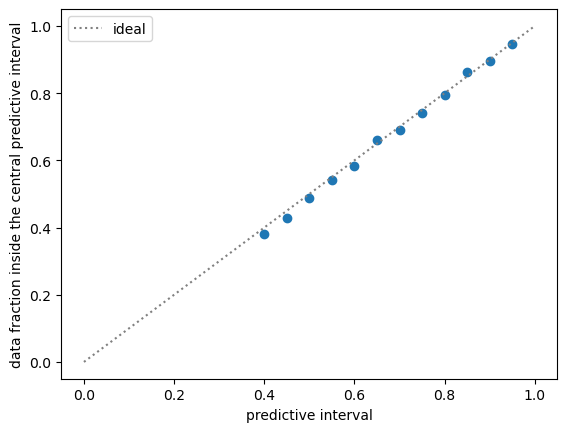

In [50]:
walphas=[]
alphas = np.arange(0.4,1.0,0.05)
for alpha in alphas:
    walpha, _, _ = within_alpha(y_test, ppcs[0].posterior_predictive["y_test"].values, alpha=alpha, axis_draws=(0, 1))
    walphas.append(walpha)


plt.scatter(alphas,walphas)
plt.ylabel('data fraction inside the central predictive interval')
plt.xlabel('predictive interval')
plt.plot([0,1],[0,1],linestyle=':',color='gray',label='ideal')
plt.legend()
plt.savefig('within.png')
plt.show()

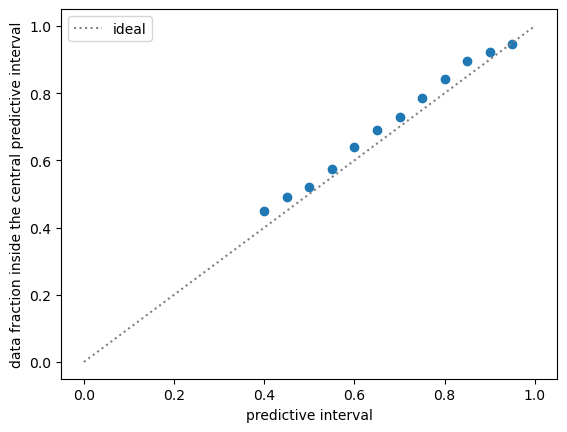

In [51]:
walphas=[]
alphas = np.arange(0.4,1.0,0.05)
for alpha in alphas:
    walpha, _, _ = within_alpha(y_test, ppcs[1].posterior_predictive["y_test"].values, alpha=alpha, axis_draws=(0, 1))
    walphas.append(walpha)


plt.scatter(alphas,walphas)
plt.ylabel('data fraction inside the central predictive interval')
plt.xlabel('predictive interval')
plt.plot([0,1],[0,1],linestyle=':',color='gray',label='ideal')
plt.legend()
plt.savefig('within.png')
plt.show()

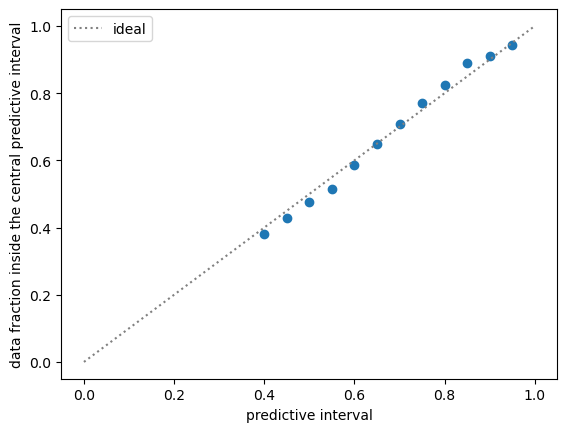

In [52]:
walphas=[]
alphas = np.arange(0.4,1.0,0.05)
for alpha in alphas:
    walpha, _, _ = within_alpha(y_test, ppcs[2].posterior_predictive["y_test"].values, alpha=alpha, axis_draws=(0, 1))
    walphas.append(walpha)


plt.scatter(alphas,walphas)
plt.ylabel('data fraction inside the central predictive interval')
plt.xlabel('predictive interval')
plt.plot([0,1],[0,1],linestyle=':',color='gray',label='ideal')
plt.legend()
plt.savefig('within.png')
plt.show()

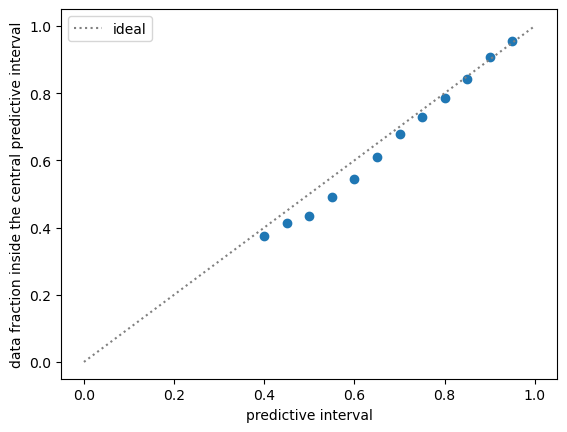

In [53]:
walphas=[]
alphas = np.arange(0.4,1.0,0.05)
for alpha in alphas:
    walpha, _, _ = within_alpha(y_test, ppcs[3].posterior_predictive["y_test"].values, alpha=alpha, axis_draws=(0, 1))
    walphas.append(walpha)


plt.scatter(alphas,walphas)
plt.ylabel('data fraction inside the central predictive interval')
plt.xlabel('predictive interval')
plt.plot([0,1],[0,1],linestyle=':',color='gray',label='ideal')
plt.legend()
plt.savefig('within.png')
plt.show()

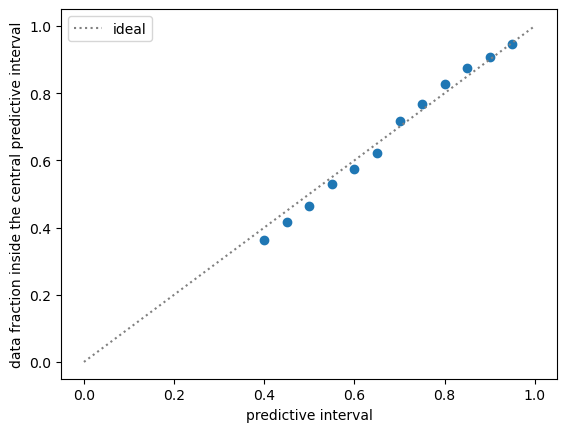

In [54]:
walphas=[]
alphas = np.arange(0.4,1.0,0.05)
for alpha in alphas:
    walpha, _, _ = within_alpha(y_test, ppcs[4].posterior_predictive["y_test"].values, alpha=alpha, axis_draws=(0, 1))
    walphas.append(walpha)


plt.scatter(alphas,walphas)
plt.ylabel('data fraction inside the central predictive interval')
plt.xlabel('predictive interval')
plt.plot([0,1],[0,1],linestyle=':',color='gray',label='ideal')
plt.legend()
plt.savefig('within.png')
plt.show()

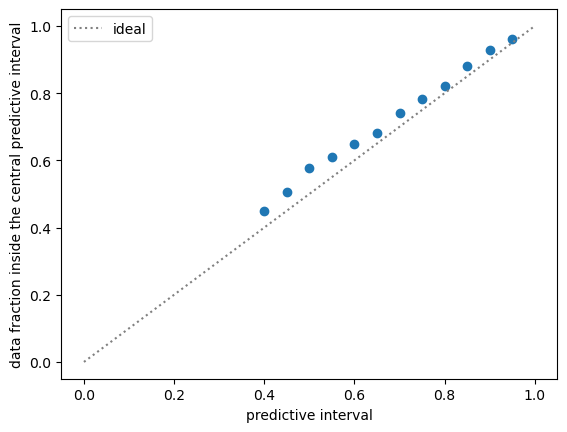

In [55]:
walphas=[]
alphas = np.arange(0.4,1.0,0.05)
for alpha in alphas:
    walpha, _, _ = within_alpha(y_test, ppcs[5].posterior_predictive["y_test"].values, alpha=alpha, axis_draws=(0, 1))
    walphas.append(walpha)


plt.scatter(alphas,walphas)
plt.ylabel('data fraction inside the central predictive interval')
plt.xlabel('predictive interval')
plt.plot([0,1],[0,1],linestyle=':',color='gray',label='ideal')
plt.legend()
plt.savefig('within.png')
plt.show()

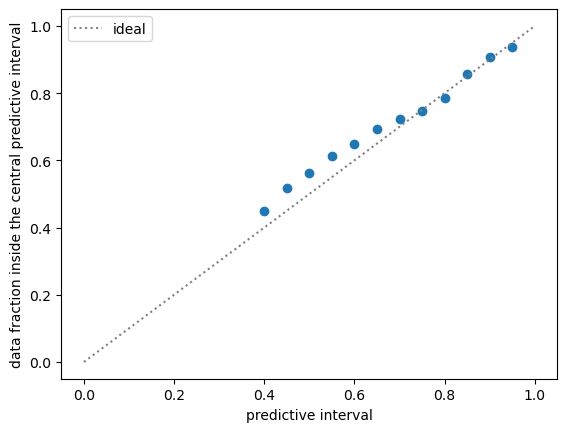

In [56]:
walphas=[]
alphas = np.arange(0.4,1.0,0.05)
for alpha in alphas:
    walpha, _, _ = within_alpha(y_test, ppcs[6].posterior_predictive["y_test"].values, alpha=alpha, axis_draws=(0, 1))
    walphas.append(walpha)


plt.scatter(alphas,walphas)
plt.ylabel('data fraction inside the central predictive interval')
plt.xlabel('predictive interval')
plt.plot([0,1],[0,1],linestyle=':',color='gray',label='ideal')
plt.legend()
plt.savefig('within.png')
plt.show()

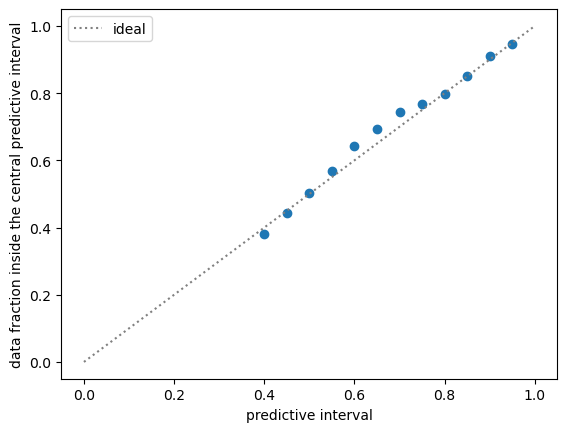

In [57]:
walphas=[]
alphas = np.arange(0.4,1.0,0.05)
for alpha in alphas:
    walpha, _, _ = within_alpha(y_test, ppcs[7].posterior_predictive["y_test"].values, alpha=alpha, axis_draws=(0, 1))
    walphas.append(walpha)


plt.scatter(alphas,walphas)
plt.ylabel('data fraction inside the central predictive interval')
plt.xlabel('predictive interval')
plt.plot([0,1],[0,1],linestyle=':',color='gray',label='ideal')
plt.legend()
plt.savefig('within.png')
plt.show()

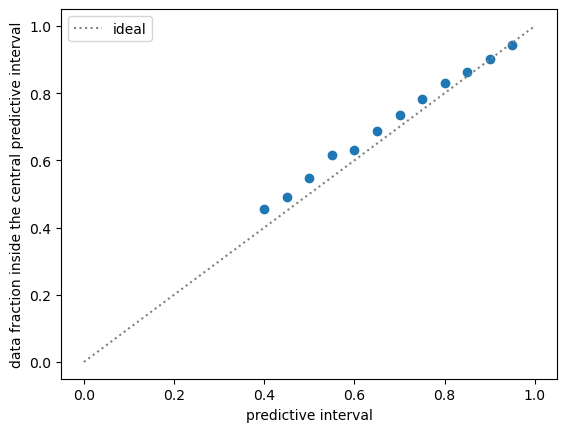

In [58]:
walphas=[]
alphas = np.arange(0.4,1.0,0.05)
for alpha in alphas:
    walpha, _, _ = within_alpha(y_test, ppcs[8].posterior_predictive["y_test"].values, alpha=alpha, axis_draws=(0, 1))
    walphas.append(walpha)


plt.scatter(alphas,walphas)
plt.ylabel('data fraction inside the central predictive interval')
plt.xlabel('predictive interval')
plt.plot([0,1],[0,1],linestyle=':',color='gray',label='ideal')
plt.legend()
plt.savefig('within.png')
plt.show()

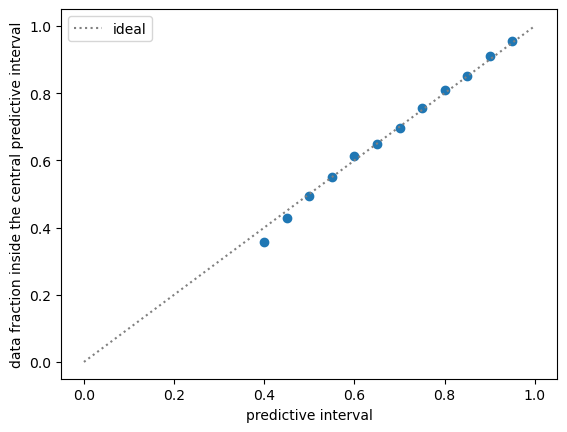

In [59]:
walphas=[]
alphas = np.arange(0.4,1.0,0.05)
for alpha in alphas:
    walpha, _, _ = within_alpha(y_test, ppcs[9].posterior_predictive["y_test"].values, alpha=alpha, axis_draws=(0, 1))
    walphas.append(walpha)


plt.scatter(alphas,walphas)
plt.ylabel('data fraction inside the central predictive interval')
plt.xlabel('predictive interval')
plt.plot([0,1],[0,1],linestyle=':',color='gray',label='ideal')
plt.legend()
plt.savefig('within.png')
plt.show()

# E vs Rest

In [8]:
kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
data = initialize_units(data_train)
T = 300
EvsRest = pd.DataFrame({
    "sample_id": [f"s{j+1}" for j in range(len(data_train['Ea']))], 
    "rho": data['density'],
    "AAV": data['AAV'],
    "PF": data_train['PF'],
    "VPA": data['VPA'],
    "NBI": data_train['NBI'],
    "SBI": data_train['SBI'],
    "RBI": data_train['RBI'],
    "WE": data_train['weighted_electronegativity'],
    "B": data_train['B'],
    "N": data_train['N'],
    "S": data_train['S'],
    "O": data_train['O'],
    "F": data_train['F'],
    "Na": data_train['Na'],
    "Al": data_train['Al'],
    "Si": data_train['Si'],
    "P": data_train['P'],
    "Cl": data_train['Cl'],
    "Ge": data_train['Ge'],
    "Br": data_train['Br'],
    "I": data_train['I'],

    # Volume
    "cub_root_V" : data['cub_root_V'],
    
    # Na–Na distances
    "Na-Na": data['Na-Na'],
    "Na-Na-max": data['Na-Na-max'],
    "Na-Na-avg": data['Na-Na-avg'],

    # Bottleneck descriptors
    "bottleneck_min": data['bottleneck_min'],
    "bottleneck_avg": data['bottleneck_avg'],

    # Polyhedral distortion
    "poly_dist_max": data_train['poly_dist_max'],
    "poly_dist_std": data_train['poly_dist_std'],
    "poly_dist_avg": data_train['poly_dist_avg'],
    "poly_dist_avg_fixed": data_train['poly_dist_avg_fixed'],

    # Voronoi face areas
    "face-area-max": data['face-area-max'],
    "face-area-avg": data['face-area-avg'],
    "face-area-min": data['face-area-min'],
    "face-area-count": data_train['face-area-count'],

    # Pockets
    "pockets-per-ion": data_train['pockets-per-ion'],
    "pockets-per-volume": data['pockets-per-volume'],

    # Paths
    "paths-per-ion": data_train['paths-per-ion'],
    "paths-per-volume": data['paths-per-volume'],

    # Target
    "E": data['E']
})    

In [9]:
n_feat = 39
EvsRest.to_csv(f"/home/paolo/Thesis/Na/data/desc_dim/Na_Ea{n_feat}_temp300_unitless.csv", index=False)
data_file = f"/home/paolo/Thesis/Na/data/desc_dim/Na_Ea{n_feat}_temp300_unitless.csv"
os.environ["SISSOPP_TUT_DAT_FILE"] = data_file

In [33]:
# Try the fit with the exact functional form
rung = 1
desc_dim = 3
Diff_json = {
    'data_file': data_file,
     'property_key': 'E',
     'desc_dim': desc_dim,
     'n_sis_select': 10,
     'max_rung': rung,
     'calc_type': 'regression',
     'min_abs_feat_val': 1e-05,
     'max_abs_feat_val': 1e8,
     'n_residual': 10,
     'n_models_store': 10,
     'leave_out_frac': 0.0,
     'leave_out_inds': [],
     'opset': ['exp', 'add', 'sub', 'mult', 'div', 'sin', 'cos']
}
json.dump(Diff_json, open(f"/home/paolo/Thesis/Na/data/desc_dim/Ea{n_feat}_{rung}_{desc_dim}_unitless.json", "w"), indent=4)

In [ ]:
# Rung=1 Desc_dim=3 Features=39 'rho': density, 'AAV': AAV, 'PF': PF, 'VPA': VPA, 'NBI': NBI, 'SBI': SBI, 'RBI': RBI, 'WE': WE, 
        # 'B': B, 'N': N, 'S': S, 'O': O, 'F': F, 'Na': Na, 'Al': Al, 'Si': Si, 'P': P, 'Cl': Cl, 'Ge': Ge, 'Br': Br, 'I': I, 'cub_root_V': V^(1/3),
        # "Na-Na": data['Na-Na'], "Na-Na-max": data['Na-Na-max'], "Na-Na-avg": data['Na-Na-avg'], "bottleneck_min": data['bottleneck_min'], "bottleneck_avg": data['bottleneck_avg'],
        # "poly_dist_max": data['poly_dist_max'], "poly_dist_std": data['poly_dist_std'], "poly_dist_avg": data['poly_dist_avg'], "poly_dist_avg_fixed": data['poly_dist_avg_fixed'],
        # "face-area-max": data['face-area-max'], "face-area-avg": data['face-area-avg'], "face-area-min": data['face-area-min'], "face-area-count": data['face-area-count'],
        # "pockets-per-ion": data['pockets-per-ion'], "pockets-per-volume": data['pockets-per-volume'],
        # "paths-per-ion": data['paths-per-ion'], "paths-per-volume": data['paths-per-volume'],
# Compiler: GNU version 11.4.0
# Compiler flags: -O3 -march=native -fopenmp
# time input_parsing: 0.0440355 s
# Time to generate feat space: 0.0201623 s
# Projection time: 0.0015664 s
# Time to get best features on rank : 8.42e-05 s
# |---Complete final combination/selection from all ranks: 0.000372 s
# Time for SIS: 0.0025746 s
# Time for l0-norm: 0.0067367 s
# Projection time: 0.0071204 s
# Time to get best features on rank : 7.55e-05 s
# |---Complete final combination/selection from all ranks: 0.0002932 s
# Time for SIS: 0.0090801 s
# Time for l0-norm: 0.0054406 s
# Projection time: 0.0050356 s
# Time to get best features on rank : 8.94e-05 s
# |---Complete final combination/selection from all ranks: 0.0002968 s
# Time for SIS: 0.0072752 s
# Time for l0-norm: 0.02505 s
# Train RMSE: 0.740741 Unitless
# c0 + a0 * (pockets-per-volume + face-area-count)

# Train RMSE: 0.688286 Unitless
# c0 + a0 * (Ge - SBI) + a1 * (face-area-count + Na-Na-max)

# Train RMSE: 0.657471 Unitless
# c0 + a0 * (Ge * S) + a1 * (poly_dist_avg_fixed - SBI) + a2 * (pockets-per-volume + face-area-count)
# Coefficients
# Task   a0                      a1                      a2                      c0
# all ,  9.091395973310664e+00,  2.650536927579654e+00, -7.452965003271551e-02,  2.252351806591994e+00, 

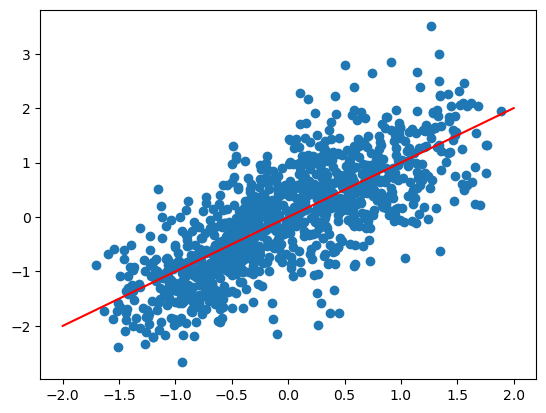

In [36]:
data = initialize_units(data_train)
a0 =  9.091395973310664e+00
a1 =  2.650536927579654e+00
a2 =  -7.452965003271551e-02
c0 = 2.252351806591994e+00
fct = c0 + a0 * (data_train['Ge'] * data_train['S']) + a1 * (data_train['poly_dist_avg_fixed'] - data_train['SBI']) + a2 * (data_train['face-area-count'] + data['pockets-per-volume'])
plt.scatter(fct, data['E'])
plt.plot([-2,2], [-2, 2], color = 'red')
plt.show()

In [7]:
def extract_dd3_Ea(ms = 10, rung=1, feat = 40):
    '''Extract the formulas and the values of the parameters from the SISSO output for desc_dim=3'''
    dd = 3
    formulas = []
    a0_list = []
    a1_list = []
    a2_list = []
    c0_list = []
    models_stored = ms
    for i in range(models_stored):
        filename = f'/home/paolo/Thesis/Na/data/desc_dim/models_Ea{feat}_{rung}_{dd}_unitless/train_dim_{dd}_model_{i}.dat'
        with open(filename, 'r') as f:
            line1 = next(f)               # First line
            for _ in range(4): next(f)    # Skip lines 2 to 5
            line6 = next(f)               # Sixth line
            formula = line1.replace('#', '').strip()
            # Split line6 by spaces
            parts = line6.strip().split()
            a0_i = parts[3].rstrip(',')
            a1_i = parts[4].rstrip(',')
            a2_i = parts[5].rstrip(',')
            c0_i = parts[6].rstrip(',')
    
            formulas.append(formula)
            a0_list.append(a0_i)
            a1_list.append(a1_i)
            a2_list.append(a2_i)
            c0_list.append(c0_i)
            #print(formula, a0_i, a1_i, c0_i)
    return(formulas, a0_list, a1_list, a2_list, c0_list)

In [8]:
raw_formulas2, a0_list2, a1_list2, a2_list2, c0_list2 =extract_dd3_Ea()

In [9]:
raw_formulas2

['c0 + a0 * (Ge * S) + a1 * (poly_dist_avg_fixed - SBI) + a2 * (pockets-per-volume + face-area-count)',
 'c0 + a0 * (Ge * S) + a1 * (poly_dist_avg - SBI) + a2 * (pockets-per-volume + face-area-count)',
 'c0 + a0 * (Ge * S) + a1 * (poly_dist_avg_fixed - SBI) + a2 * (paths-per-volume + face-area-count)',
 'c0 + a0 * (Ge * S) + a1 * (poly_dist_avg - SBI) + a2 * (paths-per-volume + face-area-count)',
 'c0 + a0 * (Ge * S) + a1 * (SBI / RBI) + a2 * (face-area-count + Na-Na-max)',
 'c0 + a0 * (Ge * S) + a1 * (poly_dist_avg_fixed - SBI) + a2 * (face-area-count + Na-Na-max)',
 'c0 + a0 * (Ge * S) + a1 * (poly_dist_avg - SBI) + a2 * (face-area-count + Na-Na-max)',
 'c0 + a0 * (Ge * S) + a1 * (SBI / RBI) + a2 * (face-area-count + Na-Na-avg)',
 'c0 + a0 * (poly_dist_std * P) + a1 * (Ge * S) + a2 * (pockets-per-volume + face-area-count)',
 'c0 + a0 * (Ge * S) + a1 * (SBI / RBI) + a2 * (face-area-count + face-area-max)']

In [10]:
def sanitize(expr):
    return (
        expr
        .replace('Na-Na-avg', 'Na_Na_avg')
        .replace('Na-Na-max', 'Na_Na_max')
        .replace('Na-Na', 'Na_Na')
        .replace('face-area-avg', 'face_area_avg')
        .replace('face-area-max', 'face_area_max')
        .replace('face-area-min', 'face_area_min')
        .replace('face-area-count', 'face_area_count')
        .replace('cub_root_V', 'cub_root_V')
        .replace('pockets-per-ion', 'pockets_per_ion')
        .replace('pockets-per-volume', 'pockets_per_volume')
        .replace('paths-per-ion', 'paths_per_ion')
        .replace('paths-per-volume', 'paths_per_volume')
    )

In [11]:
formulas2 = [sanitize(f) for f in raw_formulas2]
formulas2

['c0 + a0 * (Ge * S) + a1 * (poly_dist_avg_fixed - SBI) + a2 * (pockets_per_volume + face_area_count)',
 'c0 + a0 * (Ge * S) + a1 * (poly_dist_avg - SBI) + a2 * (pockets_per_volume + face_area_count)',
 'c0 + a0 * (Ge * S) + a1 * (poly_dist_avg_fixed - SBI) + a2 * (paths_per_volume + face_area_count)',
 'c0 + a0 * (Ge * S) + a1 * (poly_dist_avg - SBI) + a2 * (paths_per_volume + face_area_count)',
 'c0 + a0 * (Ge * S) + a1 * (SBI / RBI) + a2 * (face_area_count + Na_Na_max)',
 'c0 + a0 * (Ge * S) + a1 * (poly_dist_avg_fixed - SBI) + a2 * (face_area_count + Na_Na_max)',
 'c0 + a0 * (Ge * S) + a1 * (poly_dist_avg - SBI) + a2 * (face_area_count + Na_Na_max)',
 'c0 + a0 * (Ge * S) + a1 * (SBI / RBI) + a2 * (face_area_count + Na_Na_avg)',
 'c0 + a0 * (poly_dist_std * P) + a1 * (Ge * S) + a2 * (pockets_per_volume + face_area_count)',
 'c0 + a0 * (Ge * S) + a1 * (SBI / RBI) + a2 * (face_area_count + face_area_max)']

In [12]:
a0_2 = np.array(a0_list2, dtype=float)
a1_2 = np.array(a1_list2, dtype=float)
a2_2 = np.array(a2_list2, dtype=float)
c0_2 = np.array(c0_list2, dtype=float)

In [13]:
# define symbols
a0_sym, a1_sym, a2_sym, c0_sym = sp.symbols('a0 a1 a2 c0')
symbols = sp.symbols(
    '''
    Ea B N O F Na Al Si P S Cl Ge Br I
    density AAV PF SBI RBI VPA NBI weighted_electronegativity cub_root_V
    bottleneck_min bottleneck_avg
    poly_dist_avg poly_dist_max poly_dist_std poly_dist_avg_fixed
    Na_Na Na_Na_max Na_Na_avg
    face_area_max face_area_avg face_area_min face_area_count
    pockets_per_ion pockets_per_volume
    paths_per_ion paths_per_volume
    '''
)

locals_dict = {s.name: s for s in symbols}
# convert strings to sympy expressions
sympy_exprs = [sp.sympify(f, locals=locals_dict) for f in formulas2]

pruned = []
# Prunes the coefficients that will be added later as distributions
for f in sympy_exprs:
    row = [
        sp.simplify(f.coeff(a0_sym)),
        sp.simplify(f.coeff(a1_sym)),
        sp.simplify(f.coeff(a2_sym)),
    ]
    pruned.append(row)

pruned

[[Ge*S, -SBI + poly_dist_avg_fixed, face_area_count + pockets_per_volume],
 [Ge*S, -SBI + poly_dist_avg, face_area_count + pockets_per_volume],
 [Ge*S, -SBI + poly_dist_avg_fixed, face_area_count + paths_per_volume],
 [Ge*S, -SBI + poly_dist_avg, face_area_count + paths_per_volume],
 [Ge*S, SBI/RBI, Na_Na_max + face_area_count],
 [Ge*S, -SBI + poly_dist_avg_fixed, Na_Na_max + face_area_count],
 [Ge*S, -SBI + poly_dist_avg, Na_Na_max + face_area_count],
 [Ge*S, SBI/RBI, Na_Na_avg + face_area_count],
 [P*poly_dist_std, Ge*S, face_area_count + pockets_per_volume],
 [Ge*S, SBI/RBI, face_area_count + face_area_max]]

In [14]:
vars_ = [
    locals_dict[k] for k in [
        'B', 'N', 'S', 'O', 'F', 'Na', 'Al', 'Si', 'P', 'Cl', 'Ge', 'Br', 'I', 'density', 'AAV', 'PF', 'NBI', 'SBI', 'RBI', 'VPA', 'weighted_electronegativity', 'cub_root_V', 
        'Na_Na', 'Na_Na_max', 'Na_Na_avg', 'bottleneck_min', 'bottleneck_avg', 'poly_dist_max', 'poly_dist_std', 'poly_dist_avg', 'poly_dist_avg_fixed',
        'face_area_max', 'face_area_avg', 'face_area_min', 'face_area_count', 
        'pockets_per_ion', 'pockets_per_volume', 'paths_per_ion', 'paths_per_volume',
    ]
]
# Feature functions
Phi = [
    sp.lambdify(vars_, row, modules="numpy")
    for row in pruned
]

In [15]:
data = initialize_units(data_train)
X = np.array([
    phi(
        data_train['B'],
        data_train['N'],
        data_train['S'],
        data_train['O'],
        data_train['F'],
        data_train['Na'],
        data_train['Al'],
        data_train['Si'],
        data_train['P'],
        data_train['Cl'],
        data_train['Ge'],
        data_train['Br'],
        data_train['I'],
        
        data['density'],
        data['AAV'],
        data_train['PF'],
        data_train['NBI'],
        data_train['SBI'],
        data_train['RBI'],
        data['VPA'],
        data_train['weighted_electronegativity'],
        
        
        # Volume
        data['cub_root_V'],
        
        # Na–Na distances
        data['Na-Na'],
        data['Na-Na-max'],
        data['Na-Na-avg'],
        
        # Bottleneck descriptors
        data['bottleneck_min'],
        data['bottleneck_avg'],
        
        # Polyhedral distortion
        data_train['poly_dist_max'],
        data_train['poly_dist_std'],
        data_train['poly_dist_avg'],
        data_train['poly_dist_avg_fixed'],
        
        # Voronoi face areas
        data['face-area-max'],
        data['face-area-avg'],
        data['face-area-min'],
        data_train['face-area-count'],
        
        # Pockets
        data_train['pockets-per-ion'],
        data['pockets-per-volume'],
        
        # Paths
        data_train['paths-per-ion'],
        data['paths-per-volume'],
    )
    for phi in Phi
])

In [16]:
data2 = initialize_units(data_test)
kb = constants.physical_constants['Boltzmann constant in eV/K'][0]
T = 300
X_test = np.array([
    phi(
        data_test['B'],
        data_test['N'],
        data_test['S'],
        data_test['O'],
        data_test['F'],
        data_test['Na'],
        data_test['Al'],
        data_test['Si'],
        data_test['P'],
        data_test['Cl'],
        data_test['Ge'],
        data_test['Br'],
        data_test['I'],
        
        data2['density'],
        data2['AAV'],
        data_test['PF'],
        data_test['NBI'],
        data_test['SBI'],
        data_test['RBI'],
        data2['VPA'],
        data_test['weighted_electronegativity'],
        
        
        # Volume
        data2['cub_root_V'],
        
        # Na–Na distances
        data2['Na-Na'],
        data2['Na-Na-max'],
        data2['Na-Na-avg'],
        
        # Bottleneck descriptors
        data2['bottleneck_min'],
        data2['bottleneck_avg'],
        
        # Polyhedral distortion
        data_test['poly_dist_max'],
        data_test['poly_dist_std'],
        data_test['poly_dist_avg'],
        data_test['poly_dist_avg_fixed'],
        
        # Voronoi face areas
        data2['face-area-max'],
        data2['face-area-avg'],
        data2['face-area-min'],
        data_test['face-area-count'],
        
        # Pockets
        data_test['pockets-per-ion'],
        data2['pockets-per-volume'],
        
        # Paths
        data_test['paths-per-ion'],
        data2['paths-per-volume'],
    )
    for phi in Phi
])

In [17]:
X_test

array([[[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [-1.06919935e-01, -2.52368228e-02, -6.60289140e-02, ...,
         -8.42016417e-02,  1.23190248e-02, -9.32707232e-02],
        [ 2.60405052e+01,  6.25407986e+00,  3.99757971e+01, ...,
          4.31651829e+01,  2.63117320e+01,  2.85403576e+01]],

       [[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [-7.47754024e-02, -2.52368228e-02, -6.80455587e-02, ...,
         -8.42016417e-02,  7.94653750e-03, -2.01798271e-03],
        [ 2.60405052e+01,  6.25407986e+00,  3.99757971e+01, ...,
          4.31651829e+01,  2.63117320e+01,  2.85403576e+01]],

       [[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [-1.06919935e-01, -2.52368228e-02, -6.60289140e-02, ...,
         -8.42016417e-02,  1.23190248e-02, -9.327

In [21]:
np.max(c0_2), np.max(a0_2), np.max(a1_2), np.max(a2_2)

(np.float64(2.828552383215009),
 np.float64(28.61759998236689),
 np.float64(10.62005936585519),
 np.float64(-0.06735628186276602))

In [21]:
traces2 = []
ppcs2 = []
models_stored = 10
for i in range(models_stored):
    with pm.Model() as model:
        # Select the i-th column
        f = X[i, :, :]
        f_test = X_test[i, :, :]

        # Priors, Che valori di sigma potrei usare? 10 forse è un po' troppo
        c0_coeff = pm.Normal("c0", mu=c0_2[i], sigma=10)
        a0_coeff = pm.Normal("a0", mu=a0_2[i], sigma=10)
        a1_coeff = pm.Normal("a1", mu=a1_2[i], sigma=10)
        a2_coeff = pm.Normal("a2", mu=a2_2[i], sigma=10)
        sigma = pm.HalfNormal("sigma", sigma=2)

        # Linear parametrization
        mu = c0_coeff + a0_coeff * f[0, :] + a1_coeff * f[1, :] + a2_coeff * f[2, :]

        # Likelihood
        y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=data['E'])

        # Sample from posterior
        # Sequential montecarlo chiedi spiegazione
        trace = pm.smc.sample_smc(draws=4000, chains=4, threshold=0.5, random_seed = 123)

        # Posterior predictive for the TEST set:
        # Create a new RV for test predictions using the same parameters.
        mu_test = pm.Deterministic("mu_test", c0_coeff + a0_coeff * f_test[0, :] + a1_coeff * f_test[1, :] + a2_coeff * f_test[2, :])
        y_test_rv = pm.Normal("y_test", mu=mu_test, sigma=sigma)
        
        ppc = pm.sample_posterior_predictive(
        trace,
        var_names=["y_test"],
        random_seed=123
    )
        
        #trace = pm.sample()
        traces2.append(trace)
        ppcs2.append(ppc)
        
        idata = trace.posterior
        az.to_netcdf(idata, f"trace2_model_{i}.nc")
        az.to_netcdf(ppc, f"pp2_model_{i}.nc")

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

Sampling: [y_test]


Output()

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


...

Output()

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

Sampling: [y_test]


Output()

In [22]:
marginal_likelihoods = []
log_marginal_likelihoods = []
for i in range(models_stored):
    log_ml_raw = traces2[i].sample_stats["log_marginal_likelihood"].values
    # Flatten possible nested lists and cast to floats
    flattened = []
    for row in log_ml_raw.ravel():
        # If it’s a list, tuple, or NumPy array then flattened.extend(row) appends all items inside it (not the list itself).
        if isinstance(row, (list, tuple, np.ndarray)):
            flattened.extend(row)
        # Otherwise (a plain number or NaN) then flattened.append(row) just adds the single value.
        else:
            flattened.append(row)
    #print(flattened)
    # This ensures that everything inside flattened is a single scalar number, not a list or array.
    log_ml = np.array(flattened, dtype=float)
    # Checks that the entry is effectively a number
    log_ml = log_ml[~np.isnan(log_ml)]
    print(log_ml)
    # Computes the mean
    mean_log_ml = np.mean(log_ml)
    log_marginal_likelihoods.append(mean_log_ml)

[-1066.04529051 -1065.65915268 -1066.21457016 -1065.92971602]
[-1066.74006104 -1066.88151287 -1066.89008038 -1066.82802503]
[-1069.5053553  -1069.57875985 -1069.64882201 -1069.6715585 ]
[-1070.69563485 -1070.31990214 -1070.55488106 -1070.68981992]
[-1071.76948476 -1071.42077247 -1071.47324843 -1071.6346026 ]
[-1071.89890578 -1071.88446574 -1072.12654599 -1072.27733668]
[-1072.5683233  -1072.02158498 -1072.47551855 -1072.53117963]
[-1072.36155408 -1072.60191402 -1072.26780277 -1072.40639564]
[-1072.48375089 -1072.49966522 -1072.17516927 -1072.41550626]
[-1074.77840445 -1074.71629876 -1074.64535999 -1075.21812563]


In [23]:
# Recovers the highest ml value and its related index, i.e. model
max_ml = np.max(log_marginal_likelihoods)
argmax_ml = np.argmax(log_marginal_likelihoods)
max_ml, argmax_ml

(np.float64(-1065.962182344504), np.int64(0))

In [24]:
# Computes the marginal likelihood ratios between the given model and the benchmark
ml_diff = []
for i in range(models_stored):
    ml_diff.append(np.exp(-(log_marginal_likelihoods[argmax_ml] - log_marginal_likelihoods[i])))
ml_diff

[np.float64(1.0),
 np.float64(0.4178062444565582),
 np.float64(0.026280144866487703),
 np.float64(0.010022956691233004),
 np.float64(0.003652495228673563),
 np.float64(0.002277604143121631),
 np.float64(0.0016012522991298694),
 np.float64(0.0015848994997543324),
 np.float64(0.0016102906856978513),
 np.float64(0.00013951131299365575)]

In [25]:
np.argsort(ml_diff)

array([9, 7, 6, 8, 5, 4, 3, 2, 1, 0])

## Tempering

In [18]:
beta = np.array([1/8, 1/4, 1/2])
beta

array([0.125, 0.25 , 0.5  ])

In [19]:
max(data_train['Ea'])

0.49615056334651597

In [20]:
traces_temp = []
models_stored = 10
for i in range(models_stored):
    traces_i = []
    for j in beta:
        with pm.Model() as model:
            # Select the i-th column
            f = X[i, :, :]
            f_test = X_test[i, :, :]
    
            # Priors weakly informative
            c0_coeff = pm.Normal("c0", mu=c0_2[i], sigma=10)
            a0_coeff = pm.Normal("a0", mu=a0_2[i], sigma=10)
            a1_coeff = pm.Normal("a1", mu=a1_2[i], sigma=10)
            a2_coeff = pm.Normal("a2", mu=a2_2[i], sigma=10)
            sigma = pm.HalfNormal("sigma", sigma=10) #try lower?
    
            # Linear parametrization
            mu = c0_coeff + a0_coeff * f[0, :] + a1_coeff * f[1, :] + a2_coeff * f[2, :]
    
    
            # Standard log-likelihood
            dist = pm.Normal.dist(mu=mu, sigma=sigma)
            logp = pm.logp(dist, data_train['Ea'])

            # Tempered likelihood --> log (y| theta) = sum_n log(y_n|theta)
            pm.Potential("tempered_likelihood", j * logp.sum())
    
            # Sample from posterior
            # Sequential montecarlo
            trace = pm.smc.sample_smc(draws=8000, chains=4, threshold=0.5, random_seed = 123)
            #trace = pm.sample()
            traces_i.append(trace)
    traces_temp.append(traces_i)

Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Initializing SMC sampler...
Sampling 4 chains in 4 jobs


...

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Initializing SMC sampler...
Sampling 4 chains in 4 jobs


Output()

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


array([[<Axes: title={'center': 'c0'}>, <Axes: title={'center': 'c0'}>],
       [<Axes: title={'center': 'a0'}>, <Axes: title={'center': 'a0'}>],
       [<Axes: title={'center': 'a1'}>, <Axes: title={'center': 'a1'}>],
       [<Axes: title={'center': 'a2'}>, <Axes: title={'center': 'a2'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

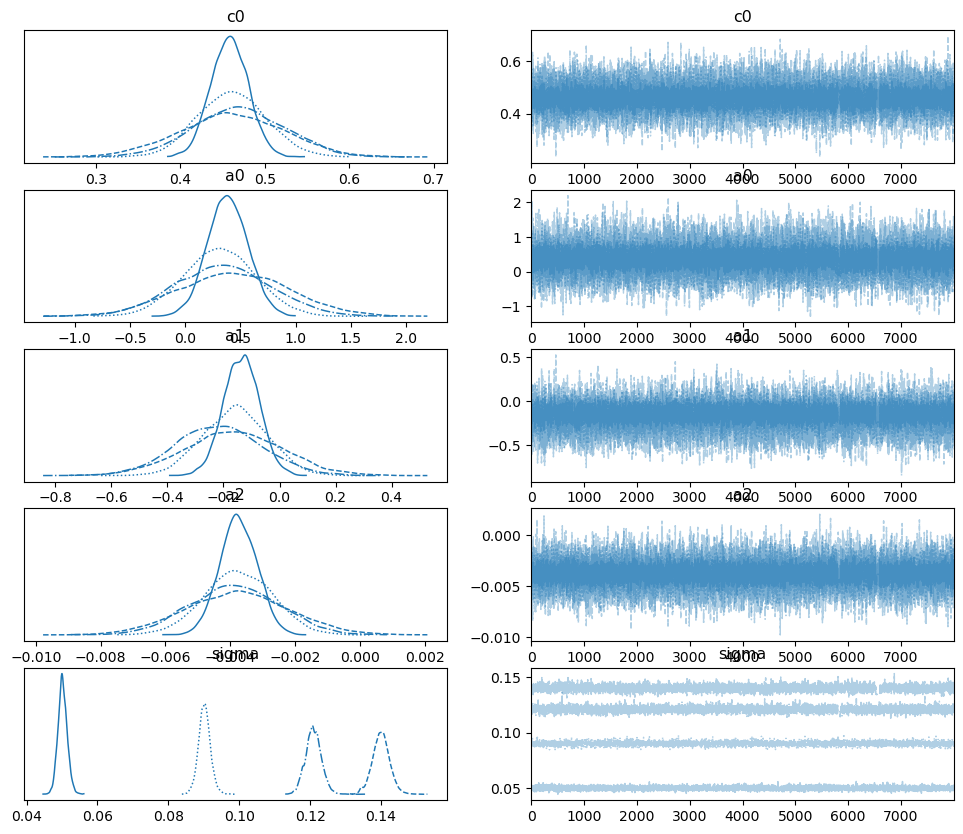

In [31]:
az.plot_trace(traces_i[0])

In [28]:
marginal_likelihoods_temp = []
log_marginal_likelihoods_temp = []
for i in range(models_stored):
    for j in range(len(beta)):
        log_ml_raw = traces_temp[i][j].sample_stats["log_marginal_likelihood"].values
    
        # Flatten possible nested lists and cast to floats
        flattened = []
        for row in log_ml_raw.ravel():
            # If it’s a list, tuple, or NumPy array then flattened.extend(row) appends all items inside it (not the list itself).
            if isinstance(row, (list, tuple, np.ndarray)):
                flattened.extend(row)
            # Otherwise (a plain number or NaN) then flattened.append(row) just adds the single value.
            else:
                flattened.append(row)
        # This ensures that everything inside flattened is a single scalar number, not a list or array.
        log_ml_temp = np.array(flattened, dtype=float)
        # Checks that the entry is effectively a number
        log_ml_temp = log_ml_temp[~np.isnan(log_ml_temp)]
        #print(log_ml_temp)
        # Computes the mean
        mean_log_ml_temp = np.mean(log_ml_temp)
        log_marginal_likelihoods_temp.append(mean_log_ml_temp)

In [22]:
log_marginal_likelihoods_temp = np.array(log_marginal_likelihoods_temp).reshape(models_stored, len(beta))

In [27]:
log_marginal_likelihoods_temp

array([[106.50171259, 250.11552487, 640.72598334],
       [120.78174624, 221.53820349, 614.23125751],
       [103.27984395, 277.93960478, 617.66170713],
       [110.91741792, 280.35889209, 574.57973734],
       [108.76658836, 308.10507011, 668.59381427],
       [109.72086759, 256.8544275 , 509.37341482],
       [ 67.35880968, 246.1446888 , 721.72646036],
       [107.76882948, 272.5249515 , 664.56740286],
       [ 97.30370746, 304.08674063, 631.73408155],
       [104.12797268, 256.98769163, 661.88906953]])

In [23]:
# For each value of beta (comlumn) finds the representative with the highest marginal likelihood
for j in range(len(beta)):
    print(np.argmax(log_marginal_likelihoods_temp[:,j]))

1
4
6


In [24]:
ml_diff_temp = []
for i in range(models_stored):
    for j in range(len(beta)):
        # log_marginal_likelihoods_temp[np.argmax(marginal_likelihoods_temp[:,j]), j] --> log_marg_likelihood of the benchmark for that value of beta
        # e.g. if j=1 --> np.argmax(marginal_likelihoods_temp[:,j]) = (1,1) --> log_marginal_likelihoods_temp[1, 1]
        ml_diff_temp.append(np.exp(-(log_marginal_likelihoods_temp[np.argmax(log_marginal_likelihoods_temp[:,j]), j] - log_marginal_likelihoods_temp[i,j])))

In [25]:
ml_diff_temp = np.array(ml_diff_temp).reshape(models_stored, len(beta))
ml_diff_temp.T # Each row corresponds to the ml difference computed with the same value of beta for the different models

array([[6.28434740e-07, 1.00000000e+00, 2.50622704e-08, 5.19968030e-05,
        6.05178141e-06, 1.57152552e-05, 6.29090958e-24, 2.23132102e-06,
        6.36234642e-11, 5.85272396e-08],
       [6.53823457e-26, 2.53797601e-38, 7.93057843e-14, 8.91226299e-13,
        1.00000000e+00, 5.52241098e-23, 1.23295805e-27, 3.52980589e-16,
        1.79829809e-02, 6.30964025e-23],
       [6.63651067e-36, 2.06740981e-47, 6.38633817e-46, 1.24448642e-64,
        8.40978696e-24, 5.97370958e-93, 1.00000000e+00, 1.50015708e-25,
        8.25669928e-40, 1.03027070e-26]])

In [26]:
# Indices corresponding to the entries sorted in ascending order for beta = 1/8, 1/4, 1/2
np.argsort(ml_diff_temp.T)

array([[6, 8, 2, 9, 0, 7, 4, 5, 3, 1],
       [1, 6, 0, 5, 9, 7, 2, 3, 8, 4],
       [5, 3, 1, 2, 8, 0, 9, 7, 4, 6]])

In [ ]:
[6, 4, 5, 1, 0, 2, 7, 3, 9, 8],
[0, 7, 5, 6, 1, 4, 9, 3, 2, 8],
[0, 5, 1, 9, 2, 3, 4, 6, 7, 8],
[6, 8, 2, 9, 0, 7, 4, 5, 3, 1],
[1, 6, 0, 5, 9, 7, 2, 3, 8, 4],
[5, 3, 1, 2, 8, 0, 9, 7, 4, 6],
[9, 7, 6, 8, 5, 4, 3, 2, 1, 0]

## Best Model

In [ ]:
files = [f"/home/paolo/Thesis/Na/mc_desc_dim_norm_Ea/trace_model_{i}.nc" for i in range(10)]
traces_list2 = [az.from_netcdf(f) for f in files]
traces2 = traces_list2

In [33]:
c0_post = []
a0_post = []
a1_post = []
a2_post = []
for m in range(models_stored):
    c0_post.append(np.mean(traces2[m].posterior['c0'].values.flatten()))
    a0_post.append(np.mean(traces2[m].posterior['a0'].values.flatten()))
    a1_post.append(np.mean(traces2[m].posterior['a1'].values.flatten()))
    a2_post.append(np.mean(traces2[m].posterior['a2'].values.flatten()))

In [44]:
a0_post[8]

np.float64(28.630927737992494)

In [43]:
c0_post_std = []
a0_post_std = []
a1_post_std = []
a2_post_std = []
for m in range(models_stored):
    c0_post_std.append(np.std(traces2[m].posterior['c0'].values.flatten()))
    a0_post_std.append(np.std(traces2[m].posterior['a0'].values.flatten()))
    a1_post_std.append(np.std(traces2[m].posterior['a1'].values.flatten()))
    a2_post_std.append(np.std(traces2[m].posterior['a2'].values.flatten()))
c0_post_std, a0_post_std

([np.float64(0.06719216792928567),
  np.float64(0.06612875936515615),
  np.float64(0.06754329997849534),
  np.float64(0.06738106366952086),
  np.float64(0.09562945386366274),
  np.float64(0.06379689992824651),
  np.float64(0.06328155336183186),
  np.float64(0.09567435578922019),
  np.float64(0.06732267021002246),
  np.float64(0.09614666890821877)],
 [np.float64(0.7652959897378567),
  np.float64(0.7577210079435767),
  np.float64(0.766912977007989),
  np.float64(0.7686060023788817),
  np.float64(0.7730460679564948),
  np.float64(0.769570534965738),
  np.float64(0.773258113058308),
  np.float64(0.7729240923997596),
  np.float64(2.6034075217815738),
  np.float64(0.7799583968550405)])

In [34]:
y_post = []
y_post_test = []
for m in range(models_stored):
    y_post.append(np.array(c0_post[m]) + X[m, 0, :] * np.array(a0_post[m]) + X[m, 1, :] * np.array(a1_post[m]) + X[m, 2, :] * np.array(a2_post[m]))
    y_post_test.append(np.array(c0_post[m]) + X_test[m, 0, :] * np.array(a0_post[m]) + X_test[m, 1, :] * np.array(a1_post[m]) + X_test[m, 2, :] * np.array(a2_post[m]))

In [35]:
y_post = np.array(y_post).T
y_post_test = np.array(y_post_test).T
y_post.shape

(1041, 10)

In [36]:
y_obs = np.tile(data['E'], (10,1)).T
y_obs

array([[ 0.67745724,  0.67745724,  0.67745724, ...,  0.67745724,
         0.67745724,  0.67745724],
       [ 1.96787596,  1.96787596,  1.96787596, ...,  1.96787596,
         1.96787596,  1.96787596],
       [-1.2712852 , -1.2712852 , -1.2712852 , ..., -1.2712852 ,
        -1.2712852 , -1.2712852 ],
       ...,
       [ 1.28468464,  1.28468464,  1.28468464, ...,  1.28468464,
         1.28468464,  1.28468464],
       [ 0.0324672 ,  0.0324672 ,  0.0324672 , ...,  0.0324672 ,
         0.0324672 ,  0.0324672 ],
       [ 2.49603244,  2.49603244,  2.49603244, ...,  2.49603244,
         2.49603244,  2.49603244]], shape=(1041, 10))

In [37]:
np.mean((y_obs - y_post)**2, axis = 0)

array([0.43226775, 0.43290224, 0.43523921, 0.43599278, 0.43697039,
       0.4372434 , 0.43766528, 0.43784622, 0.43974578, 0.43989482])

In [40]:
y_obs_test = np.tile(data_test['Ea'], (10,1)).T
y_obs_test

array([[0.30424834, 0.30424834, 0.30424834, ..., 0.30424834, 0.30424834,
        0.30424834],
       [0.35450612, 0.35450612, 0.35450612, ..., 0.35450612, 0.35450612,
        0.35450612],
       [0.26887668, 0.26887668, 0.26887668, ..., 0.26887668, 0.26887668,
        0.26887668],
       ...,
       [0.31292379, 0.31292379, 0.31292379, ..., 0.31292379, 0.31292379,
        0.31292379],
       [0.35414314, 0.35414314, 0.35414314, ..., 0.35414314, 0.35414314,
        0.35414314],
       [0.35537194, 0.35537194, 0.35537194, ..., 0.35537194, 0.35537194,
        0.35537194]], shape=(261, 10))

In [42]:
np.mean((y_obs_test - y_post_test)**2, axis = 0)

array([0.58442678, 0.57043355, 0.58274909, 0.56912411, 0.56796953,
       0.58150119, 0.56818903, 0.57652455, 0.57866394, 0.57737954])

## Calibration

In [26]:
np.random.seed(10)
c0_samples_list = []
a0_samples_list = []
a1_samples_list = []
a2_samples_list = []
sigma_samples_list = []
for m in range(models_stored):
# Draws 50 samples of the parameters from the posterior distribution
    c0_samples_list.append(np.random.choice(traces2[m].posterior['c0'].values.flatten(), size=200, replace=True))
    a0_samples_list.append(np.random.choice(traces2[m].posterior['a0'].values.flatten(), size=200, replace=True))
    a1_samples_list.append(np.random.choice(traces2[m].posterior['a1'].values.flatten(), size=200, replace=True))
    a2_samples_list.append(np.random.choice(traces2[m].posterior['a2'].values.flatten(), size=200, replace=True))
    sigma_samples_list.append(np.random.choice(traces2[m].posterior['sigma'].values.flatten(), size=200, replace=True))
c0_samples = np.array(c0_samples_list).T
a0_samples = np.array(a0_samples_list).T
a1_samples = np.array(a1_samples_list).T
a2_samples = np.array(a2_samples_list).T
sigma_samples = np.array(sigma_samples_list).T

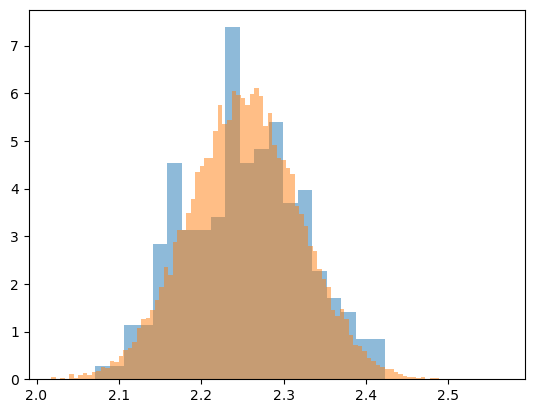

In [27]:
plt.hist(np.array(c0_samples.T[0]), alpha = 0.5, bins = 20, density = True)
plt.hist(traces2[0].posterior['c0'].values.flatten(), bins = 100, alpha = 0.5, density = True)
plt.show()

In [28]:
inputs = 1041
y_emp = np.zeros((inputs, models_stored))
for i in range(inputs):
    for m in range(models_stored):
        # Computes the mean over the ensemble for each of the 1041 points for each of the 10 formulas
        f = X[m, :, :]
        y_emp[i, m] = np.mean(c0_samples[:,m] + X[m, 0, i] * a0_samples[:,m] + X[m, 1, i] * a1_samples[:,m] + X[m, 2, i] * a2_samples[:,m])
# Empirical mean over the models
y_emp

array([[ 0.43178926,  0.42777828,  0.42953202, ...,  0.26833076,
         0.44897687,  0.28981066],
       [ 0.57829874,  0.58102326,  0.5813601 , ...,  0.22366287,
         0.42595889,  0.21341084],
       [-0.9548754 , -0.92715135, -0.94527596, ..., -0.75443243,
        -0.8964205 , -0.77987127],
       ...,
       [ 1.20402693,  1.15786238,  1.20381805, ...,  0.9775751 ,
         1.07423054,  0.99995825],
       [ 0.01397264, -0.0158848 ,  0.04503594, ..., -0.10368889,
        -0.24542992, -0.15666445],
       [ 1.33336225,  1.27654026,  1.32045231, ...,  1.25113216,
         0.95168424,  1.2067535 ]], shape=(1041, 10))

In [29]:
inputs = 1041
var_emp = np.zeros((inputs, models_stored))
for i in range(inputs):
    for m in range(models_stored):
        # Computes the variance over the ensemble for each of the 1041 points for each of the 10 formulas
        #var_emp[i, m] = np.var((c0_samples + Phi[i, m] * a0_samples + sigma_samples - y_emp[i,m])**2), ddof = 1)
        # Assuming decorrelation between noise and parameters
        f = X[m, :, :]
        var_emp[i, m] = 1/(200-1) * np.sum((c0_samples[:,m] + X[m, 0, i] * a0_samples[:,m] + X[m, 1, i] * a1_samples[:,m] + X[m, 2, i] * a2_samples[:,m] - y_emp[i,m])**2 
                                           + sigma_samples[:,m]**2)
# Empirical variance over the models
var_emp

array([[0.44354232, 0.4434731 , 0.4477859 , ..., 0.45897143, 0.45157314,
        0.46039907],
       [0.44542248, 0.445299  , 0.44956727, ..., 0.4581921 , 0.45302597,
        0.46032503],
       [0.44685541, 0.44706157, 0.45218628, ..., 0.4627637 , 0.45464547,
        0.46566985],
       ...,
       [0.44137701, 0.44116019, 0.44503867, ..., 0.45945587, 0.44782107,
        0.45982146],
       [0.44505995, 0.44502683, 0.44957539, ..., 0.45957477, 0.45243385,
        0.4620767 ],
       [0.44196059, 0.44148928, 0.44551997, ..., 0.45540279, 0.44805449,
        0.45687011]], shape=(1041, 10))

In [30]:
y_obs = np.tile(data['E'], (10,1)).T
y_obs

array([[ 0.67745724,  0.67745724,  0.67745724, ...,  0.67745724,
         0.67745724,  0.67745724],
       [ 1.96787596,  1.96787596,  1.96787596, ...,  1.96787596,
         1.96787596,  1.96787596],
       [-1.2712852 , -1.2712852 , -1.2712852 , ..., -1.2712852 ,
        -1.2712852 , -1.2712852 ],
       ...,
       [ 1.28468464,  1.28468464,  1.28468464, ...,  1.28468464,
         1.28468464,  1.28468464],
       [ 0.0324672 ,  0.0324672 ,  0.0324672 , ...,  0.0324672 ,
         0.0324672 ,  0.0324672 ],
       [ 2.49603244,  2.49603244,  2.49603244, ...,  2.49603244,
         2.49603244,  2.49603244]], shape=(1041, 10))

In [31]:
# Columnwise mean of the given vector, i.e. mean over the features
R = np.mean((y_obs - y_emp)**2/var_emp, axis = 0)
R

array([0.97166301, 0.97301887, 0.96827269, 0.96857925, 0.94779271,
       0.97642973, 0.96578012, 0.94823414, 0.97255205, 0.95001203])

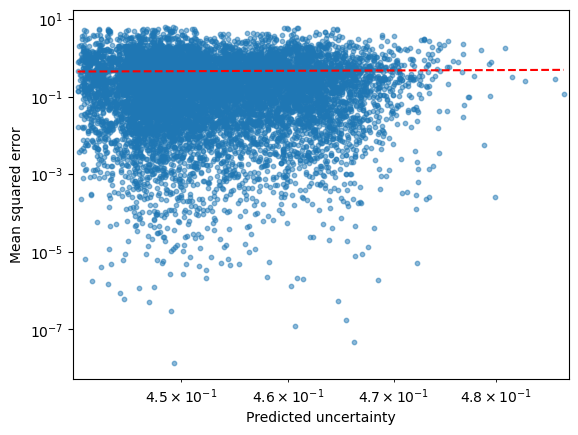

In [45]:
mse = np.abs(y_emp - y_obs)**2
plt.scatter(var_emp, mse, s=10, alpha=0.5)

# x limits based on data
xmin = var_emp[var_emp > 0].min()
xmax = var_emp.max()
plt.xlim(xmin*0.999, xmax*1.001)

# bisecting line y = x over the same range
xline = np.logspace(np.log10(xmin), np.log10(xmax), 200)
plt.plot(xline, xline, 'r--')

plt.loglog()
plt.xlabel("Predicted uncertainty")
plt.ylabel("Mean squared error")
plt.show()

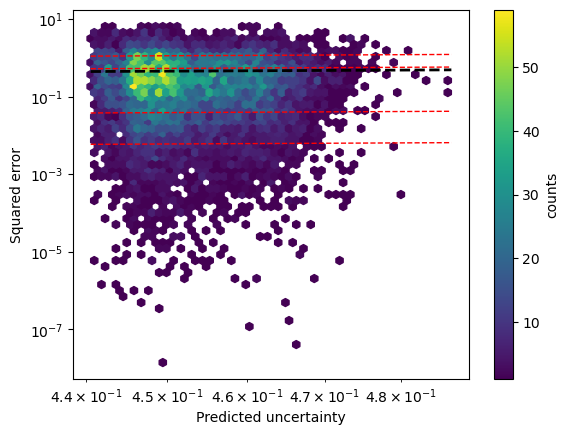

In [46]:
x = var_emp
y = (y_obs - y_emp)**2
# reference line
xmin, xmax = x.min(), x.max()
xline = np.logspace(np.log10(xmin), np.log10(xmax), 300)
plt.plot(xline, xline, 'k--', lw=2, label='y = x')

# quantiles in log space
log_ratios = np.log10(y / x)
quantiles = [0.1, 0.25, 0.75, 0.9]

for q in quantiles:
    q_val = 10 ** np.quantile(log_ratios, q)
    plt.plot(xline, q_val * xline,
             linestyle='--',
             color='red',
             lw=1)

# hexbin
plt.hexbin(x, y, gridsize=50, xscale='log', yscale='log',
           mincnt=1, cmap='viridis')

plt.colorbar(label='counts')
plt.xlabel("Predicted uncertainty")
plt.ylabel("Squared error")
plt.xscale('log')
plt.yscale('log')
#plt.ylim(xmin,xmax)
#plt.savefig('quant.png')
plt.show()

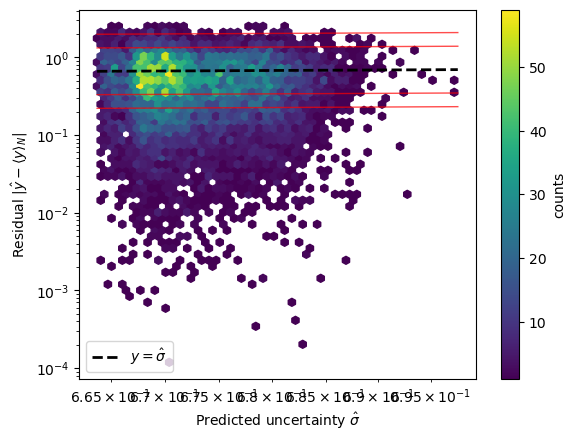

In [47]:
x = np.sqrt(var_emp)  # predicted uncertainty σ̂
y = np.abs(y_obs - y_emp)  # empirical error (not squared)

# reference line y = x  (error = σ)
xmin, xmax = x.min(), x.max()
xline = np.logspace(np.log10(xmin), np.log10(xmax), 300)
plt.plot(xline, xline, 'k--', lw=2, label=r'$y = \hat{\sigma}$')

# sigma lines: y = n·σ
sigma_multipliers = [1/3, 1/2, 2, 3]
for n in sigma_multipliers:
    plt.plot(xline, n * xline,
             linestyle='-',
             color='red',
             lw=1,
             alpha=0.7)

# hexbin
plt.hexbin(x, y, gridsize=50, xscale='log', yscale='log',
           mincnt=1, cmap='viridis')
plt.colorbar(label='counts')
plt.xlabel(r'Predicted uncertainty $\hat{\sigma}$')
plt.ylabel(r'Residual $|\hat y - \langle y \rangle_N|$')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

In [ ]:
files_ppc2 = [f"/home/paolo/Thesis/Na/pp_desc_dim_norm_Ea/pp_model_{i}.nc" for i in range(10)]
ppcs2 = [az.from_netcdf(f) for f in files_ppc2]

In [48]:
# ----------------------------
# Metric: W_alpha or Prediction Interval Coverage Probability (PICP)
# ----------------------------
def within_alpha(y_true, y_pred_samples, alpha: float, axis_draws=(0, 1)):
    """
    W_alpha: proportion of y_true inside the central alpha predictive interval.

    y_pred_samples shape examples:
      (chain, draw, n_obs)  -> axis_draws=(0,1)
      (draw, n_obs)         -> axis_draws=(0,)
    """
    y_true = np.asarray(y_true)

    if not (0.0 < alpha < 1.0):
        raise ValueError("alpha must be in (0, 1), e.g. 0.50 or 0.95. It represents a fraction!")

    # Centering of the uncertainty --> If alpha=95 then 5% of the observations will fall outside this interval and they will be split into le lowest and highest quantiles
    # the lowest quantile will be 5/2 = 2.5 and the highest quantile 100 - 2.5 = 97.5
    q_low = (1.0 - alpha) / 2.0
    q_high = 1.0 - q_low

    lower = np.quantile(y_pred_samples, q_low, axis=axis_draws)
    upper = np.quantile(y_pred_samples, q_high, axis=axis_draws)

    # Checks whether the true value lies inside the given interval
    inside = (y_true >= lower) & (y_true <= upper)
    # Computes the mean over the inner values
    return float(np.mean(inside)), lower, upper

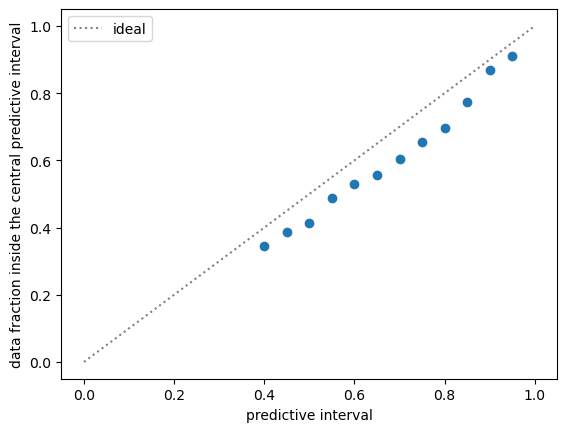

In [56]:
walphas=[]
y_test = np.array(data_test['Ea'])
alphas = np.arange(0.4,1.0,0.05)
for alpha in alphas:
    walpha, _, _ = within_alpha(y_test, ppcs2[0].posterior_predictive["y_test"].values, alpha=alpha, axis_draws=(0, 1))
    walphas.append(walpha)


plt.scatter(alphas,walphas)
plt.ylabel('data fraction inside the central predictive interval')
plt.xlabel('predictive interval')
plt.plot([0,1],[0,1],linestyle=':',color='gray',label='ideal')
plt.legend()
#plt.savefig('within.png')
plt.show()